# Retail Demand Signals and Projections (Olist)

This project uses historical order data to identify recurring high demand periods by product category. The operational goal is to help sellers prepare for demand increases that tend to repeat over the year. The dataset comes from Olist, which operates as an intermediary layer between sellers and consumer facing marketplaces. In this setup, sellers do not directly control demand generation, but they must plan inventory, staffing, and processing capacity to handle incoming orders.

The analysis covers September 2016 through October 2018. The focus is not on predicting exact future volumes, but on projecting recurring seasonal patterns forward to provide early signals for the next planning cycle.

## Data source

The dataset used in this analysis comes from the publicly available Olist e-commerce dataset: https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce.


## Loading the data and confirming time coverage

This analysis uses four tables. Orders provides the purchase timestamp. Order items provides item level revenue and product identifiers. Products provides product category. A translation table provides an English label for categories.

Before building category demand, the first step is confirming the time span of recorded purchases.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from pathlib import Path
# from prophet import Prophet  # Commenting out as it's not installed

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

def resolve_data_dir():
    candidates = [
        Path("."),
        Path("./olist"),
        Path("../olist"),
        Path("/mnt/data"),
        Path("/mnt/data/olist"),
    ]
    for c in candidates:
        if (c / "olist_orders_dataset.csv").exists():
            return c
    raise FileNotFoundError(
        "Could not find the Olist CSV files. Place them in the current folder or in an 'olist' folder."
    )

DATA_DIR = resolve_data_dir()

paths = {
    "orders": DATA_DIR / "olist_orders_dataset.csv",
    "order_items": DATA_DIR / "olist_order_items_dataset.csv",
    "products": DATA_DIR / "olist_products_dataset.csv",
    "category_translation": DATA_DIR / "product_category_name_translation.csv",
}

orders = pd.read_csv(paths["orders"], parse_dates=["order_purchase_timestamp"])
order_items = pd.read_csv(paths["order_items"])
products = pd.read_csv(paths["products"])
category_translation = pd.read_csv(paths["category_translation"])

time_min = orders["order_purchase_timestamp"].min()
time_max = orders["order_purchase_timestamp"].max()

pd.DataFrame(
    {
        "table": ["orders", "order_items", "products", "category_translation"],
        "rows": [len(orders), len(order_items), len(products), len(category_translation)],
    }
), time_min, time_max

(                  table    rows
 0                orders   99441
 1           order_items  112650
 2              products   32951
 3  category_translation      71,
 Timestamp('2016-09-04 21:15:19'),
 Timestamp('2018-10-17 17:30:18'))

## Data integrity check

Before building the daily series, a lightweight integrity check is used to confirm that the core tables do not contain fully duplicated rows and that the key fields required for order aggregation are not missing. This check is descriptive and does not apply any cleaning steps.

In [2]:
# Fully duplicated rows (exact duplicates)
dup_orders = orders.duplicated().sum()
dup_order_items = order_items.duplicated().sum()
dup_products = products.duplicated().sum()

# Missing values in key fields used in this analysis
missing_orders = orders[["order_id", "order_purchase_timestamp"]].isna().sum()
missing_order_items = order_items[["order_id"]].isna().sum()
missing_products = products[["product_category_name"]].isna().sum()

integrity_summary = pd.DataFrame(
    {
        "fully_duplicated_rows": [dup_orders, dup_order_items, dup_products],
        "missing_key_fields": [
            int(missing_orders.sum()),
            int(missing_order_items.sum()),
            int(missing_products.sum()),
        ],
    },
    index=["orders", "order_items", "products"],
)

integrity_summary


,fully_duplicated_rows,missing_key_fields
orders,0,0
order_items,0,0
products,0,610


A small number of missing values is present in some fields, but they do not affect the key identifiers and timestamps required to build daily order volumes. Because the analysis focuses on aggregated patterns and category level signals, the expected impact of these missing values is minimal, so no corrective action is applied and the dataset is used as is.

## Visualization settings

The charts in this project follow a consistent formatting standard.

In [3]:
BLUE = "#1f77b4"
ORANGE = "#ff7f0e"

# Figure sizing
FIGSIZE = (14, 5)
plt.rcParams["figure.figsize"] = FIGSIZE

def pretty_category(name: str) -> str:
    if pd.isna(name):
        return name
    return str(name).replace("_", " ").title()

def format_mb(x: float) -> str:
    if abs(x) >= 1e9:
        return f"{x / 1e9:.1f}B"
    if abs(x) >= 1e6:
        return f"{x / 1e6:.1f}M"
    return f"{x:.1f}" if abs(x) < 100 else f"{x:,.0f}"

def apply_y_axis_format(ax, values):
    vmax = float(np.nanmax(values)) if len(values) else 0.0
    if vmax >= 1e9:
        scale, suffix = 1e9, "B"
    elif vmax >= 1e6:
        scale, suffix = 1e6, "M"
    else:
        scale, suffix = 1.0, ""
    ax.yaxis.set_major_formatter(FuncFormatter(lambda v, pos: f"{v/scale:g}{suffix}" if scale != 1.0 else f"{v:g}"))
    ax.get_yaxis().get_offset_text().set_visible(False)
    return scale, suffix

def add_bar_value_labels(ax, scale=1.0, suffix=""):
    for p in ax.patches:
        height = p.get_height()
        label_val = height / scale if scale else height
        label = f"{label_val:.1f}{suffix}" if suffix else f"{label_val:.1f}"
        ax.annotate(
            label,
            (p.get_x() + p.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 3),
            textcoords="offset points",
            fontsize=9,
        )

## Defining revenue and selecting the top 10 categories

The dataset includes more than 70 product categories. To keep analytical depth and produce actionable outputs, the analysis focuses on the top 10 categories by historical revenue. Revenue is defined as the sum of item prices recorded in the order items table. All subsequent steps restrict the data to these categories.

In [4]:
items = (
    order_items
    .merge(products[["product_id", "product_category_name"]], on="product_id", how="left")
    .merge(category_translation, on="product_category_name", how="left")
    .merge(orders[["order_id", "order_purchase_timestamp"]], on="order_id", how="left")
)

items["category"] = items["product_category_name_english"].fillna("unknown")
items["price"] = pd.to_numeric(items["price"], errors="coerce")
items = items.dropna(subset=["order_purchase_timestamp", "price"])

category_revenue = (
    items.loc[items["category"] != "unknown"]
    .groupby("category", as_index=False)["price"].sum()
    .sort_values("price", ascending=False)
    .rename(columns={"price": "revenue"})
)

top10 = category_revenue.head(10).copy()
top10_share = top10["revenue"].sum() / category_revenue["revenue"].sum()

top10, top10_share

(                 category     revenue
 43          health_beauty  1258681.34
 70          watches_gifts  1205005.68
 7          bed_bath_table  1036988.68
 65         sports_leisure   988048.97
 15  computers_accessories   911954.32
 39        furniture_decor   729762.49
 20             cool_stuff   635290.85
 49             housewares   632248.66
 5                    auto   592720.11
 42           garden_tools   485256.46,
 0.632223038747454)

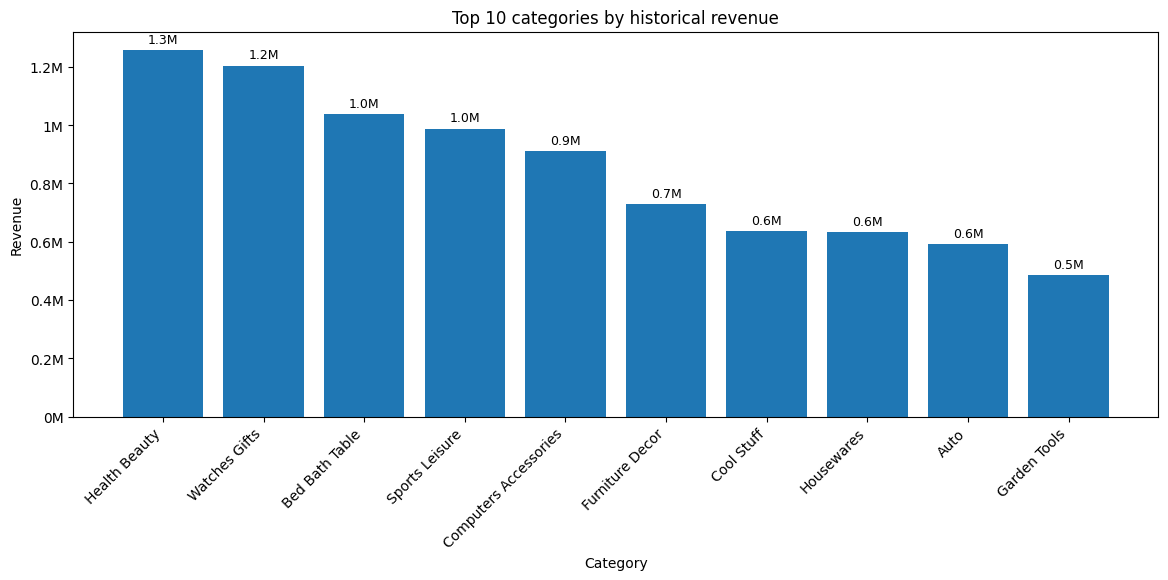

In [5]:
plt.figure(figsize=FIGSIZE)
x_labels = top10["category"].map(pretty_category)
ax = plt.gca()
ax.bar(x_labels, top10["revenue"], color=BLUE)

scale, suffix = apply_y_axis_format(ax, top10["revenue"])
add_bar_value_labels(ax, scale, suffix)

ax.set_title("Top 10 categories by historical revenue")
ax.set_xlabel("Category")
ax.set_ylabel("Revenue")
plt.xticks(rotation=45, ha="right")
plt.show()


A small subset of categories concentrates a large share of historical revenue. Focusing on this subset improves interpretability and reduces noise from sparse categories, while still covering most economic activity in the dataset.

In [6]:
top10_categories = top10["category"].tolist()
items_top = items[items["category"].isin(top10_categories)].copy()
items_top["date"] = items_top["order_purchase_timestamp"].dt.floor("D")
items_top.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english,order_purchase_timestamp,category,date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29,cool_stuff,cool_stuff,2017-09-13 08:59:02,cool_stuff,2017-09-13
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87,moveis_decoracao,furniture_decor,2018-01-14 14:33:31,furniture_decor,2018-01-14
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.9,18.14,ferramentas_jardim,garden_tools,2017-02-04 13:57:51,garden_tools,2017-02-04
5,00048cc3ae777c65dbb7d2a0634bc1ea,1,ef92defde845ab8450f9d70c526ef70f,6426d21aca402a131fc0a5d0960a3c90,2017-05-23 03:55:27,21.9,12.69,utilidades_domesticas,housewares,2017-05-15 21:42:34,housewares,2017-05-15
7,000576fe39319847cbb9d288c5617fa6,1,557d850972a7d6f792fd18ae1400d9b6,5996cddab893a4652a15592fb58ab8db,2018-07-10 12:30:45,810.0,70.75,ferramentas_jardim,garden_tools,2018-07-04 12:08:27,garden_tools,2018-07-04


## Building daily demand series by category

Demand is represented as daily order volume by category. The unit of demand is an order, not an item, because operational preparation often scales with the number of orders to pick, pack, and hand off. Orders can include items from multiple categories. In that case, the same order contributes to multiple category series, which reflects that multiple category teams may experience workload from the same purchase event.

The series is built by counting unique orders per day for each category and filling missing days to create a continuous calendar.

In [7]:
def build_daily_orders_by_category(df_items, categories):
    start = df_items["date"].min()
    end = df_items["date"].max()
    full_index = pd.date_range(start, end, freq="D")

    frames = []
    for cat in categories:
        sub = df_items[df_items["category"] == cat][["date", "order_id"]].dropna()
        daily = (
            sub.groupby("date", as_index=False)["order_id"]
            .nunique()
            .rename(columns={"order_id": "orders"})
            .set_index("date")
            .reindex(full_index)
            .rename_axis("date")
            .fillna({"orders": 0})
            .reset_index()
        )
        daily["category"] = cat
        frames.append(daily)

    out = pd.concat(frames, ignore_index=True)
    out = out[["category", "date", "orders"]]
    return out

daily_cat = build_daily_orders_by_category(items_top, top10_categories)
daily_cat.head(), daily_cat.tail()

(        category       date  orders
 0  health_beauty 2016-09-04     0.0
 1  health_beauty 2016-09-05     0.0
 2  health_beauty 2016-09-06     0.0
 3  health_beauty 2016-09-07     0.0
 4  health_beauty 2016-09-08     0.0,
           category       date  orders
 7245  garden_tools 2018-08-25     4.0
 7246  garden_tools 2018-08-26     0.0
 7247  garden_tools 2018-08-27     1.0
 7248  garden_tools 2018-08-28     0.0
 7249  garden_tools 2018-08-29     0.0)

In [8]:
daily_summary = (
    daily_cat.groupby("category")["orders"]
    .agg(["mean", "median", "std", "max"])
    .sort_values("mean", ascending=False)
)

daily_summary

,mean,median,std,max
category,,,,
bed_bath_table,12.988966,13.0,10.980640,157.0
health_beauty,12.187586,10.0,10.499572,82.0
sports_leisure,10.648276,10.0,8.528091,79.0
computers_accessories,9.226207,7.0,8.811634,62.0
furniture_decor,8.895172,8.0,7.200755,89.0
housewares,8.115862,7.0,7.006929,49.0
watches_gifts,7.757241,6.0,7.756950,68.0
auto,5.375172,4.0,5.257191,42.0
cool_stuff,5.009655,5.0,3.986672,29.0


## Historical demand patterns

This section looks at demand over time to identify recurring patterns that sellers can use for planning. The focus is on seasonality and the shape of demand, not on predicting exact values.

The first view shows the full daily history for each top category. The second view compresses the history into average demand by month of year and by day of week, which are directly usable as planning references.

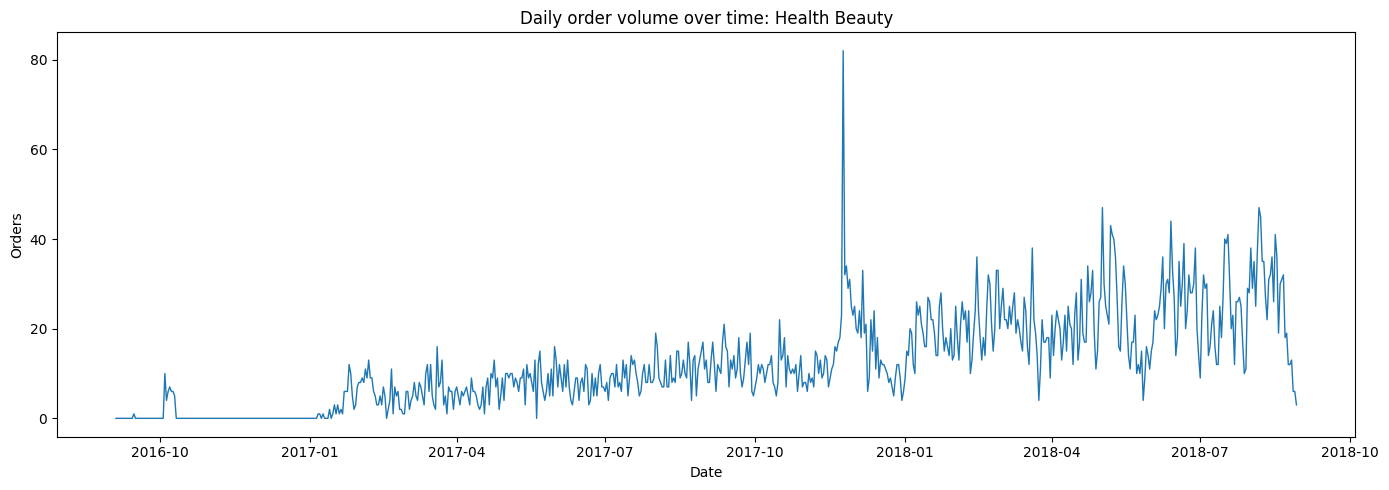

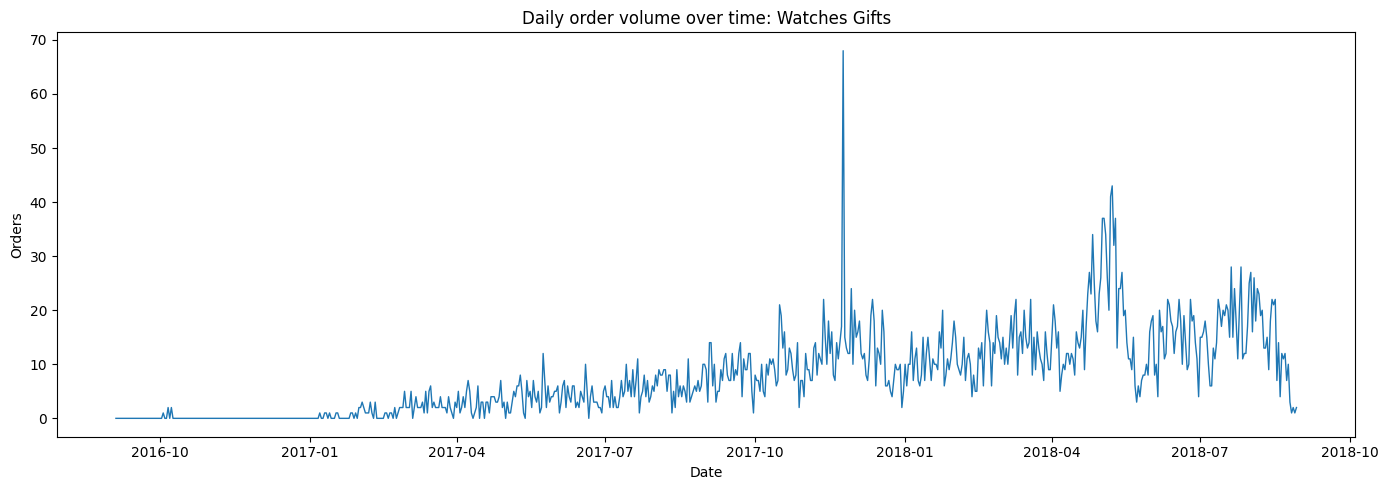

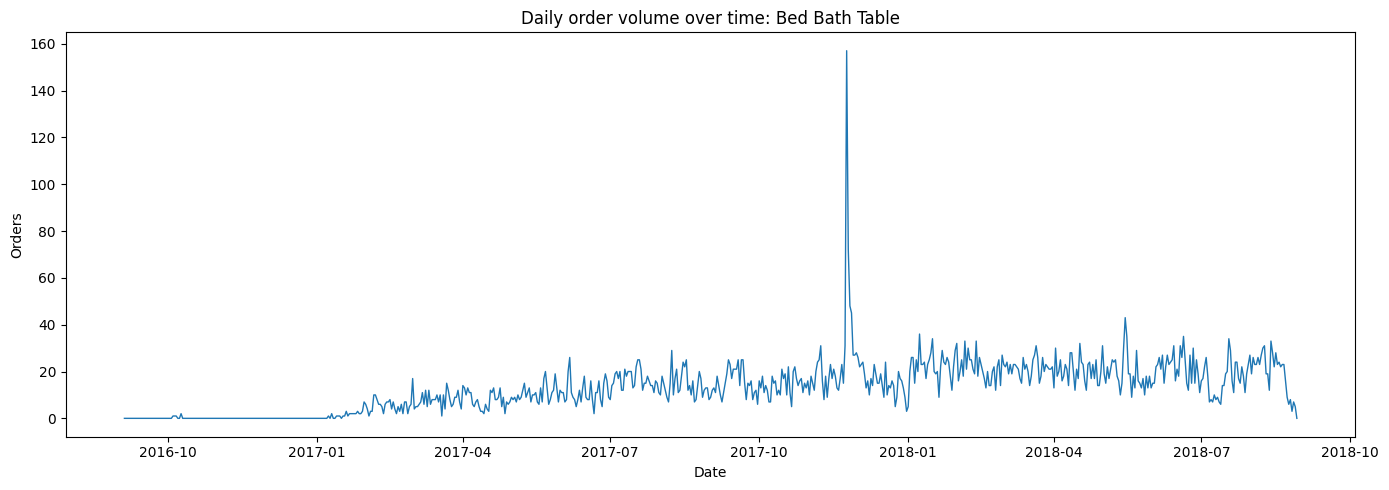

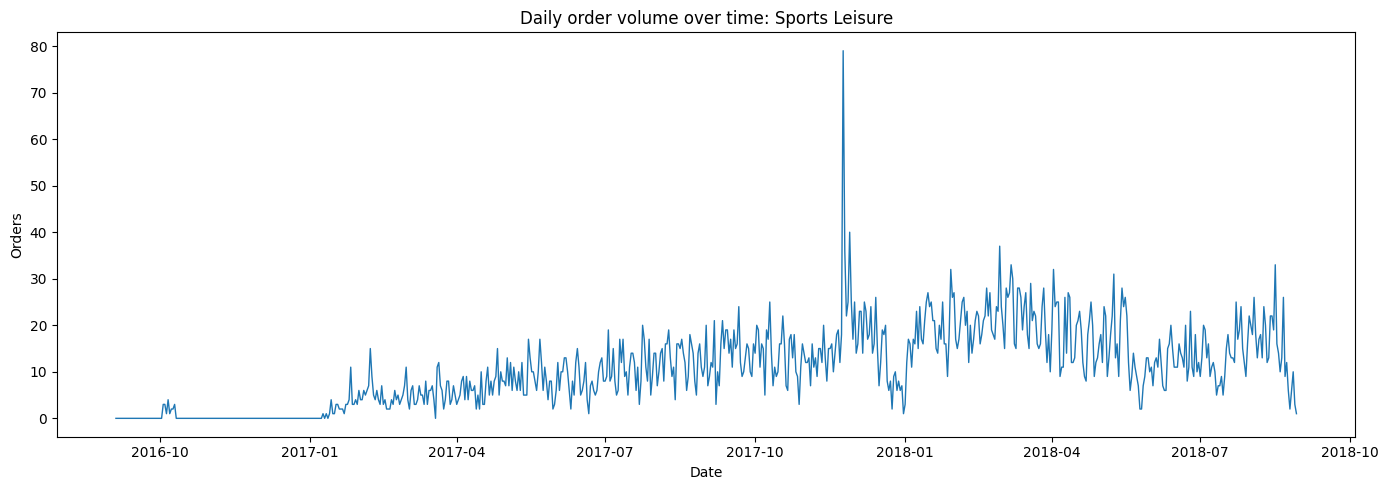

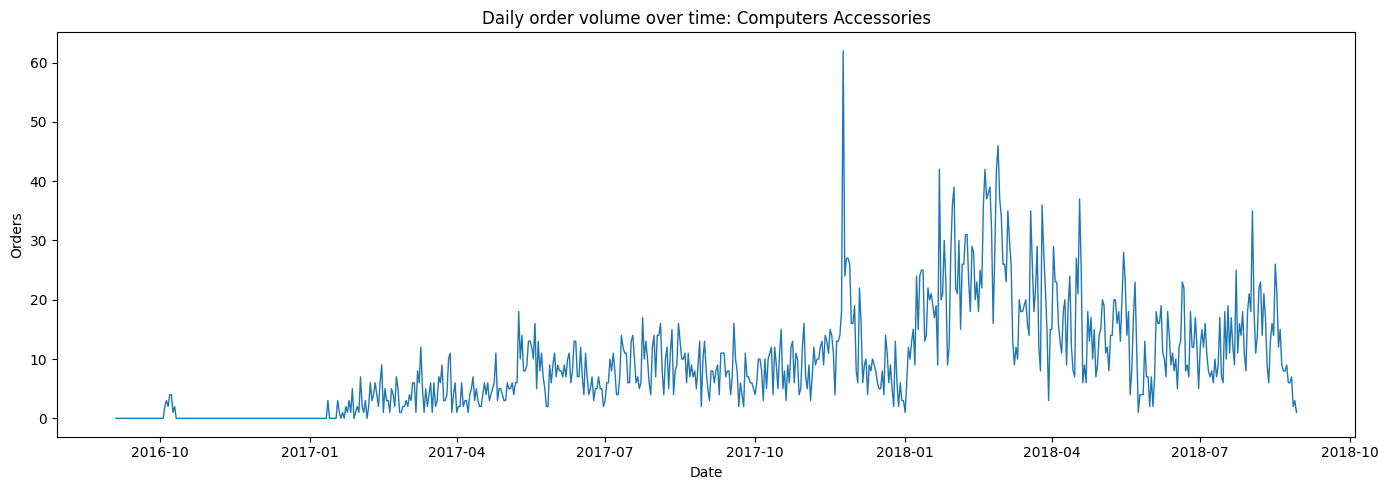

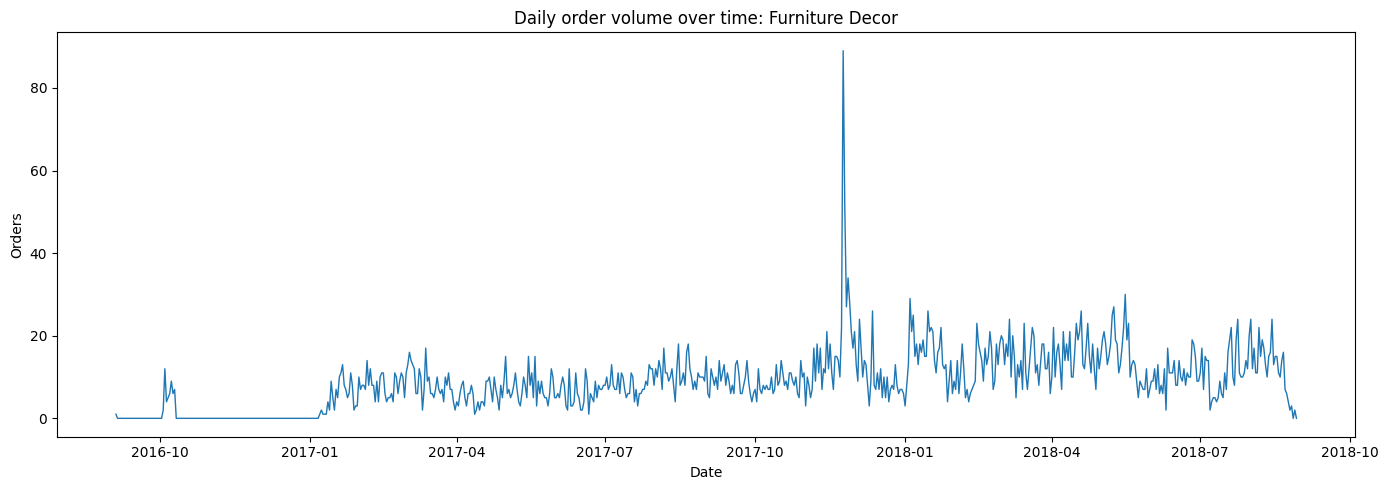

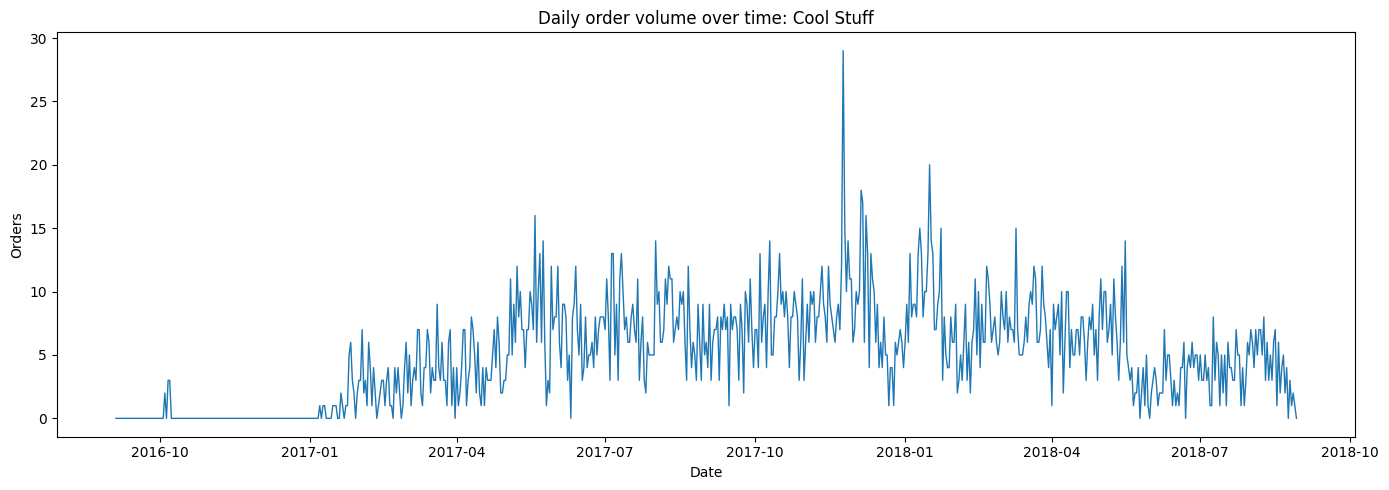

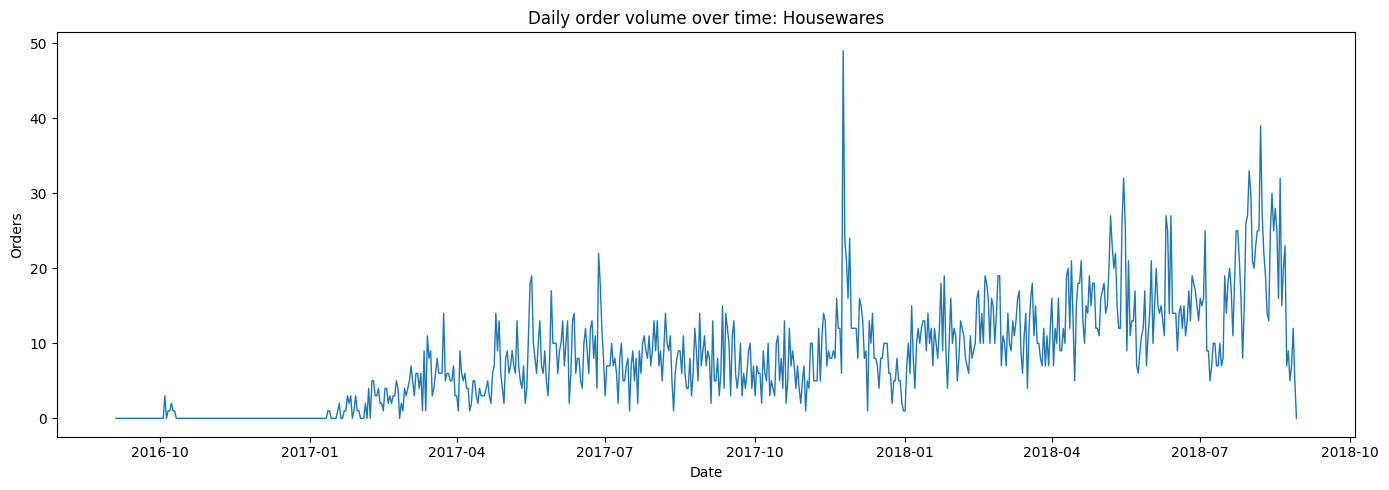

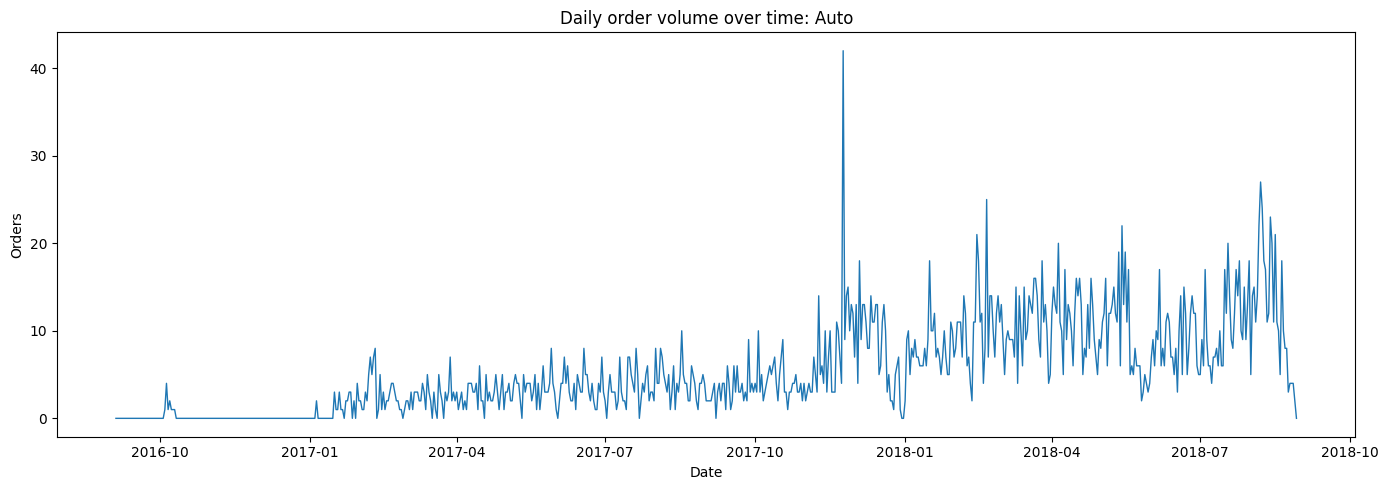

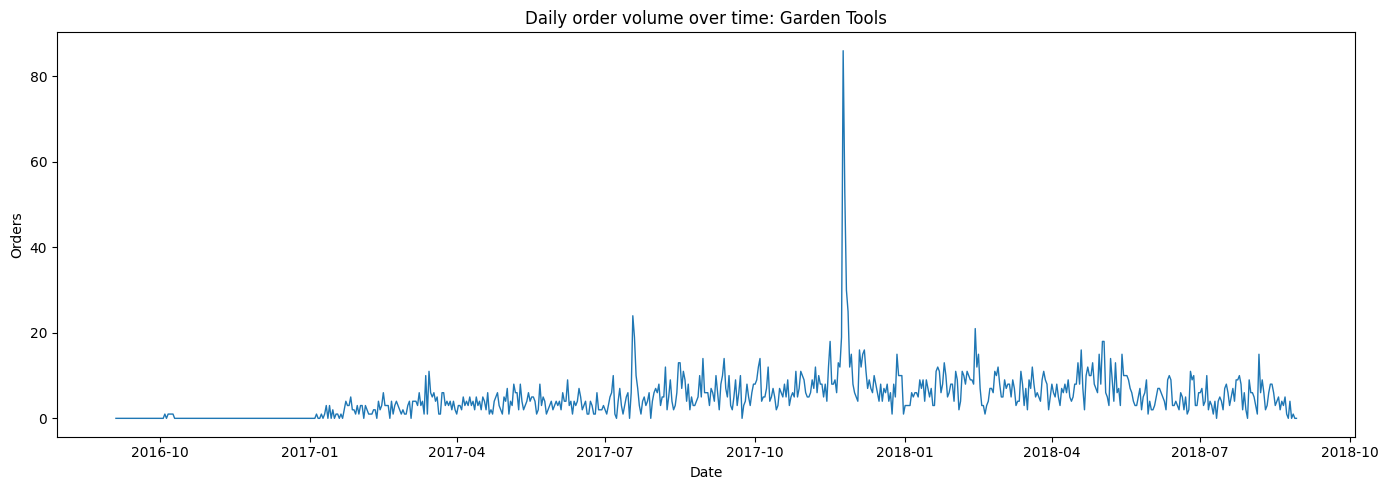

In [9]:
for cat in top10_categories:
    sub = daily_cat[daily_cat["category"] == cat].copy()
    plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    ax.plot(sub["date"], sub["orders"], color=BLUE, linewidth=1)

    apply_y_axis_format(ax, sub["orders"])

    ax.set_title(f"Daily order volume over time: {pretty_category(cat)}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Orders")
    plt.tight_layout()
    plt.show()

Across all top categories, daily order volume shows one extreme spike on November 24, 2017. This day stands out far above surrounding dates and should be treated as an outlier rather than a recurring seasonal pattern. Outside of this event, categories differ in how concentrated their peaks are. Categories with sharper and more concentrated peaks require earlier preparation and larger buffers, while steadier categories can rely more on regular weekly rhythm.

In [10]:
daily_cat["month"] = daily_cat["date"].dt.month
daily_cat["month_name"] = daily_cat["date"].dt.strftime("%b")
daily_cat["dow"] = daily_cat["date"].dt.dayofweek
dow_labels = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
daily_cat["dow_name"] = daily_cat["dow"].map(dow_labels)

month_order = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

monthly_profile = (
    daily_cat.groupby(["category", "month_name"], as_index=False)["orders"].mean()
)
monthly_profile["month_name"] = pd.Categorical(monthly_profile["month_name"], categories=month_order, ordered=True)

dow_profile = (
    daily_cat.groupby(["category", "dow_name"], as_index=False)["orders"].mean()
)
dow_order = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_profile["dow_name"] = pd.Categorical(dow_profile["dow_name"], categories=dow_order, ordered=True)

monthly_profile.head(), dow_profile.head()

(  category month_name    orders
 0     auto        Apr  6.950000
 1     auto        Aug  8.083333
 2     auto        Dec  3.919355
 3     auto        Feb  6.785714
 4     auto        Jan  4.419355,
   category dow_name    orders
 0     auto      Fri  5.165049
 1     auto      Mon  6.230769
 2     auto      Sat  4.310680
 3     auto      Sun  3.884615
 4     auto      Thu  5.864078)

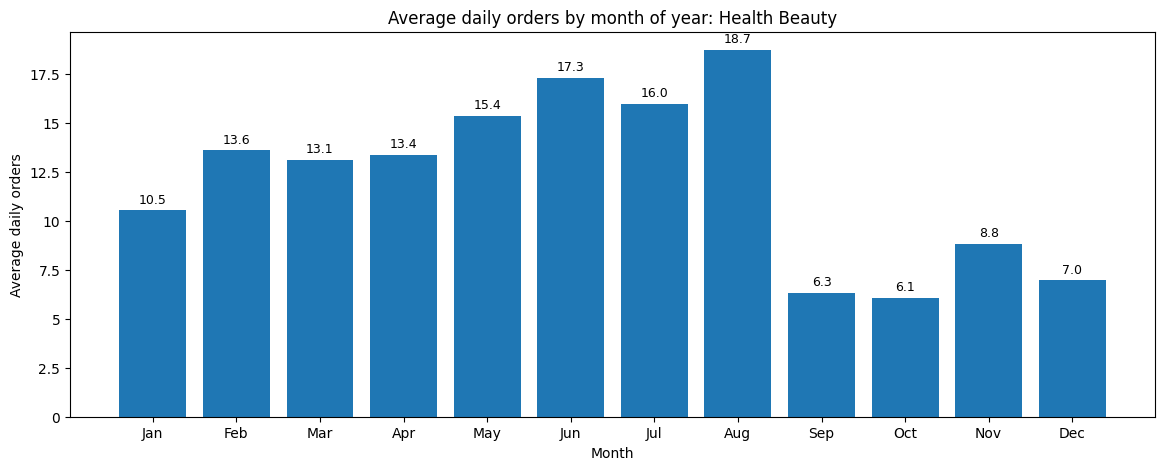

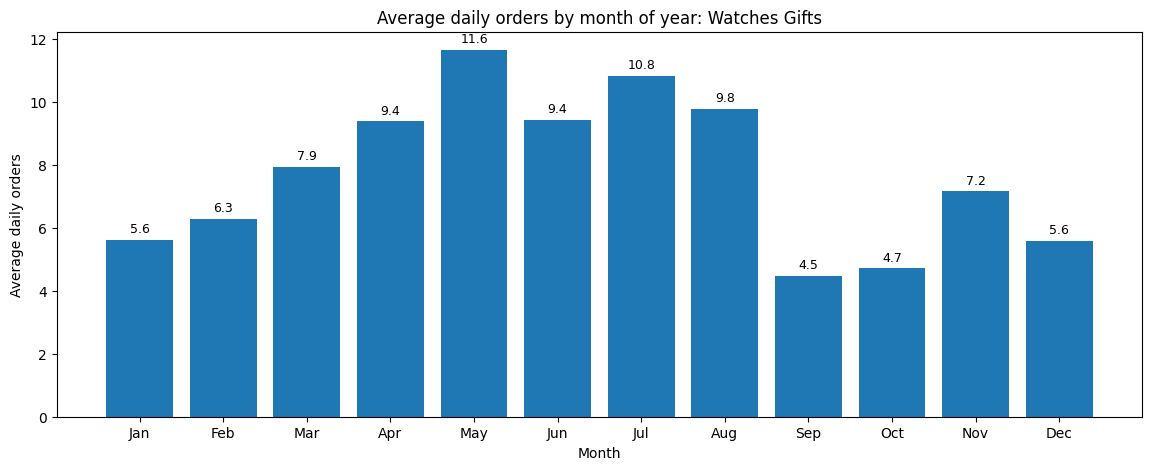

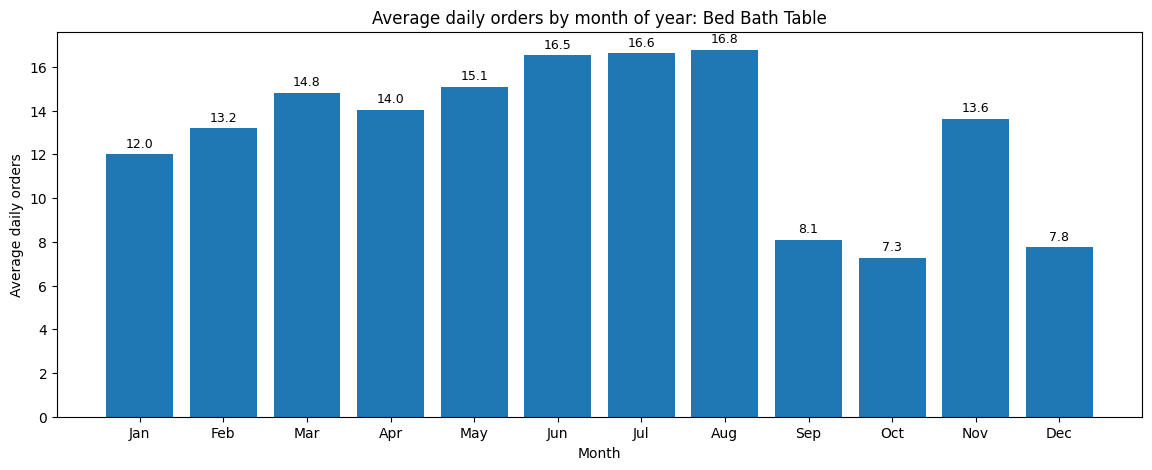

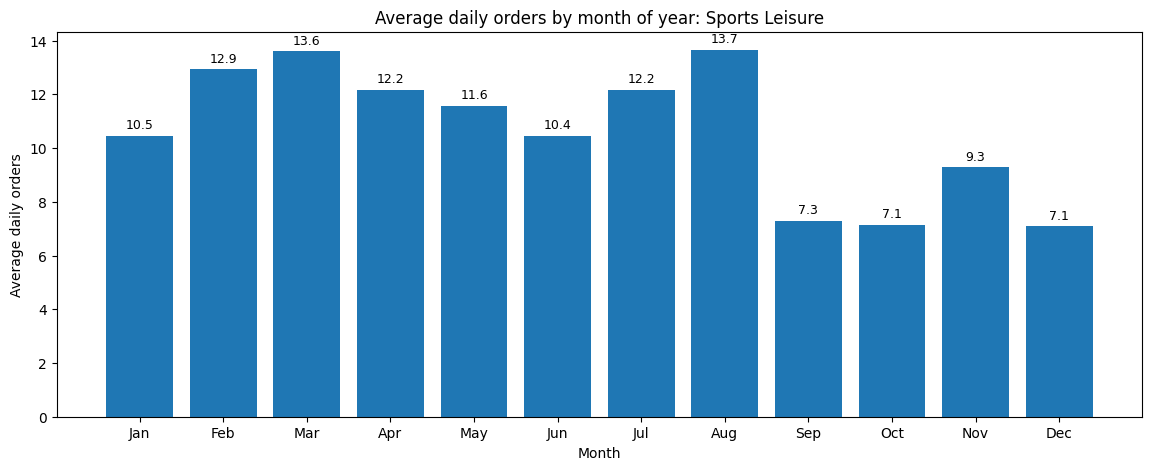

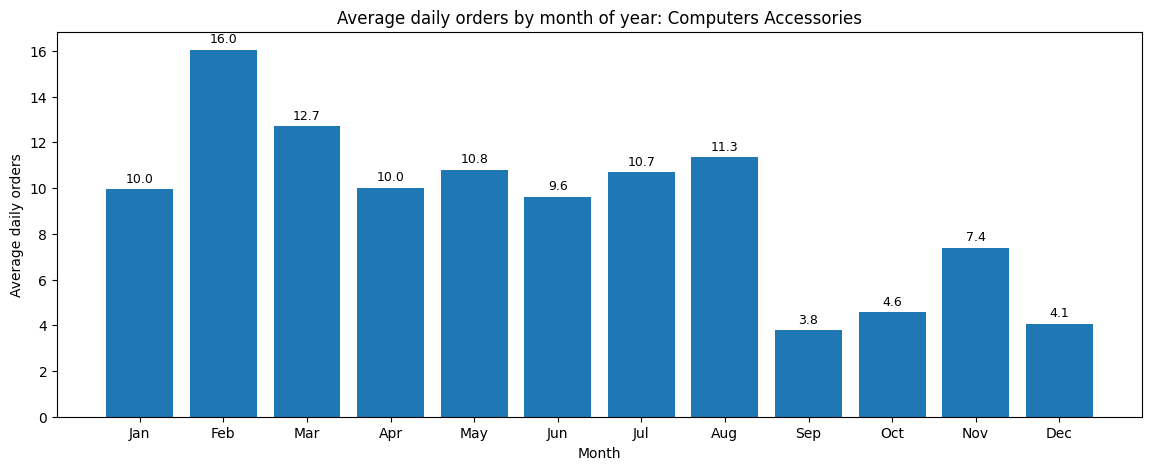

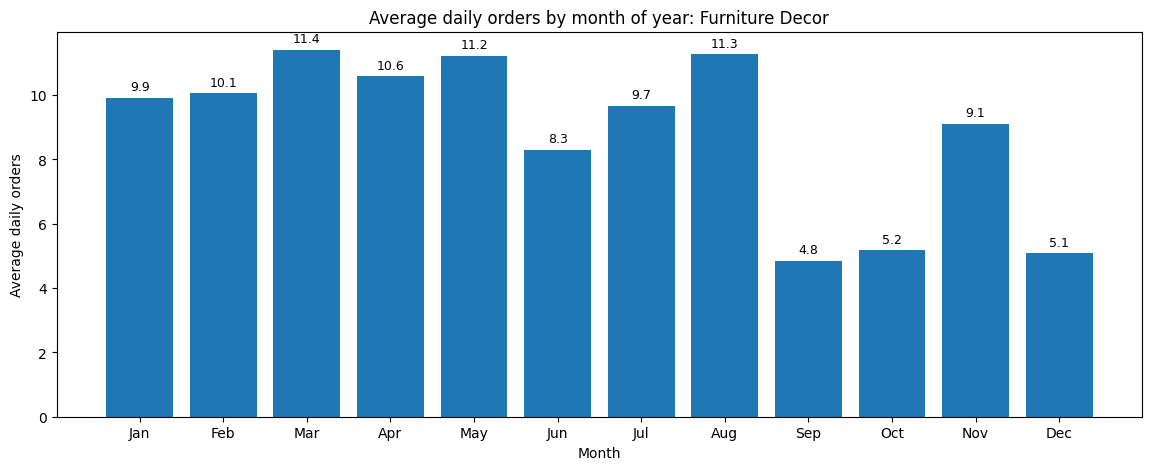

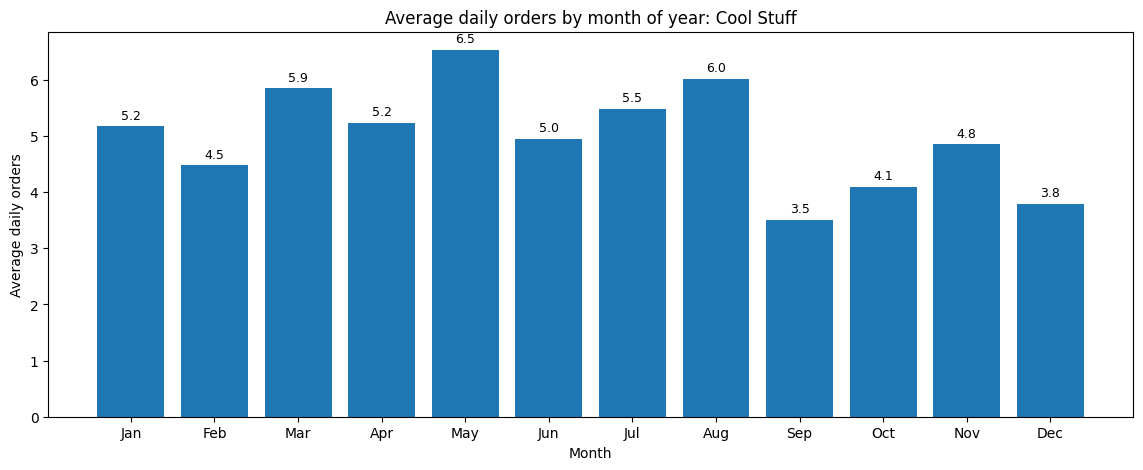

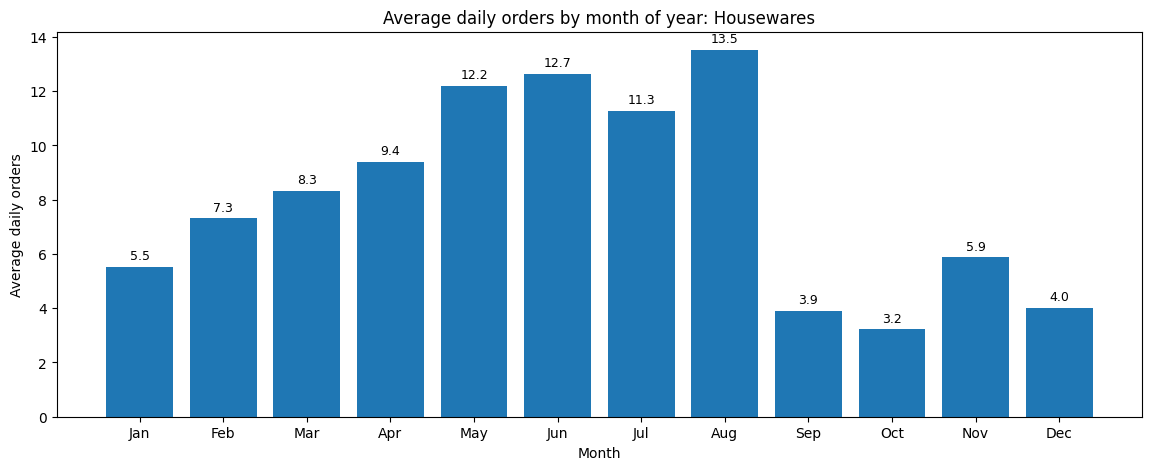

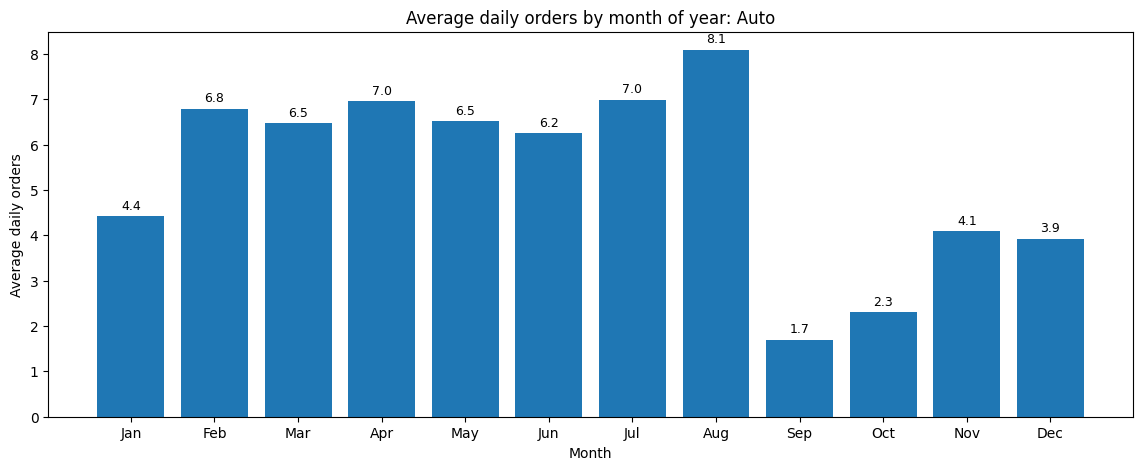

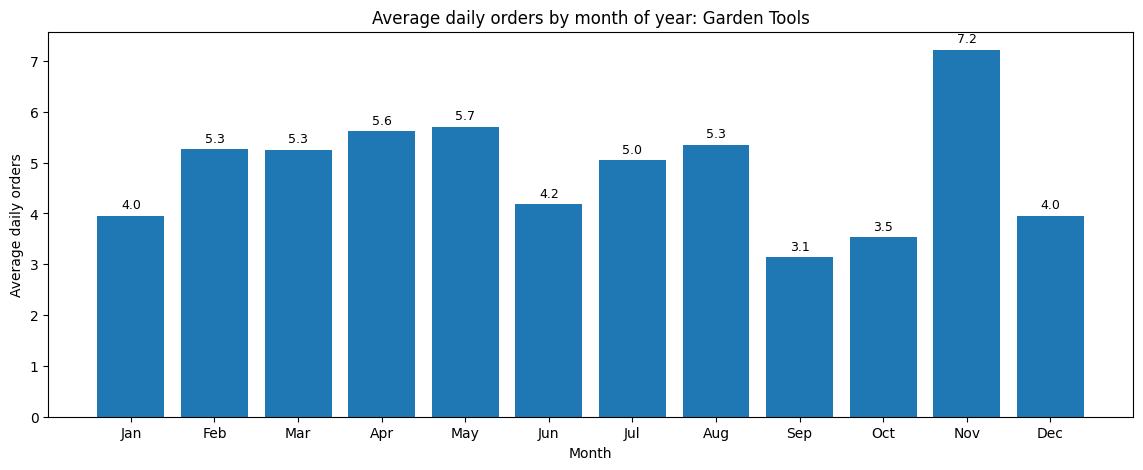

In [11]:
for cat in top10_categories:
    sub = monthly_profile[monthly_profile["category"] == cat].sort_values("month_name")
    plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    ax.bar(sub["month_name"].astype(str), sub["orders"], color=BLUE)

    scale, suffix = apply_y_axis_format(ax, sub["orders"])
    add_bar_value_labels(ax, scale, suffix)

    ax.set_title(f"Average daily orders by month of year: {pretty_category(cat)}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Average daily orders")
    plt.show()


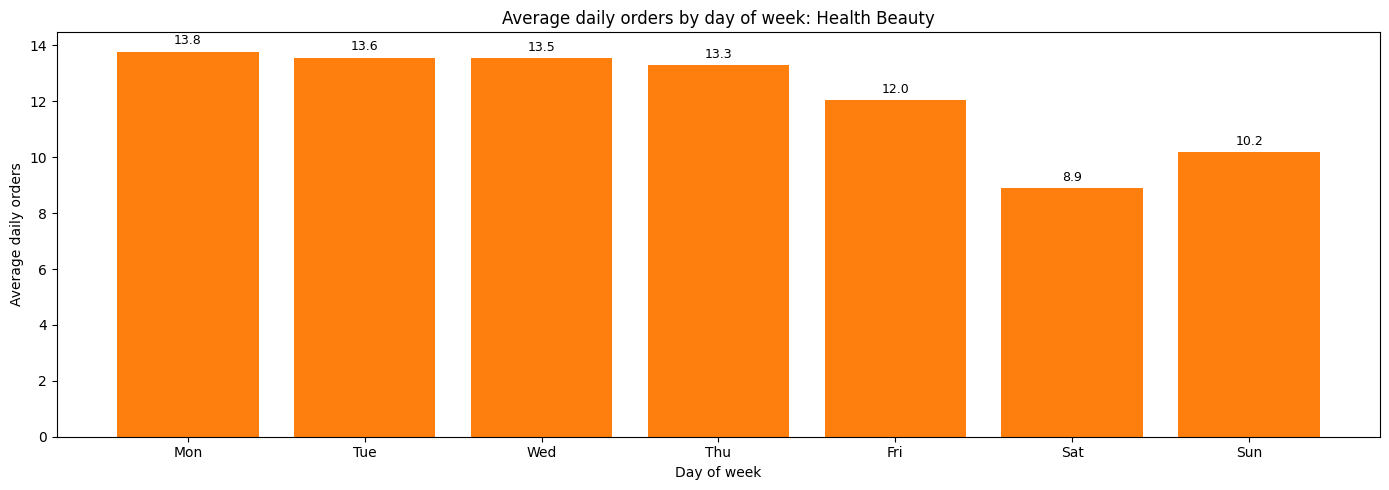

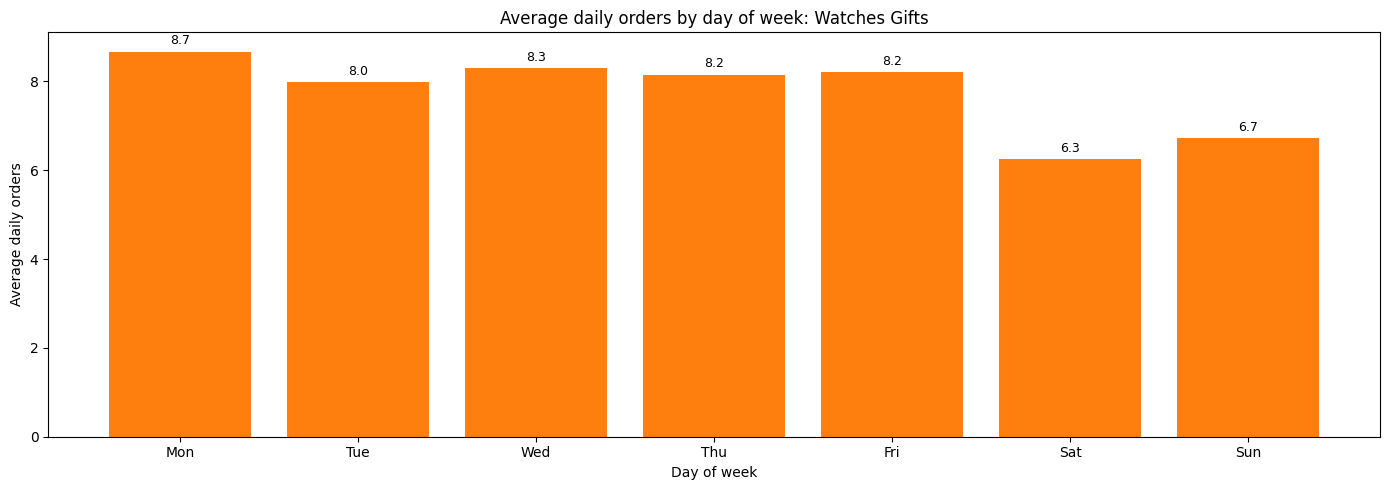

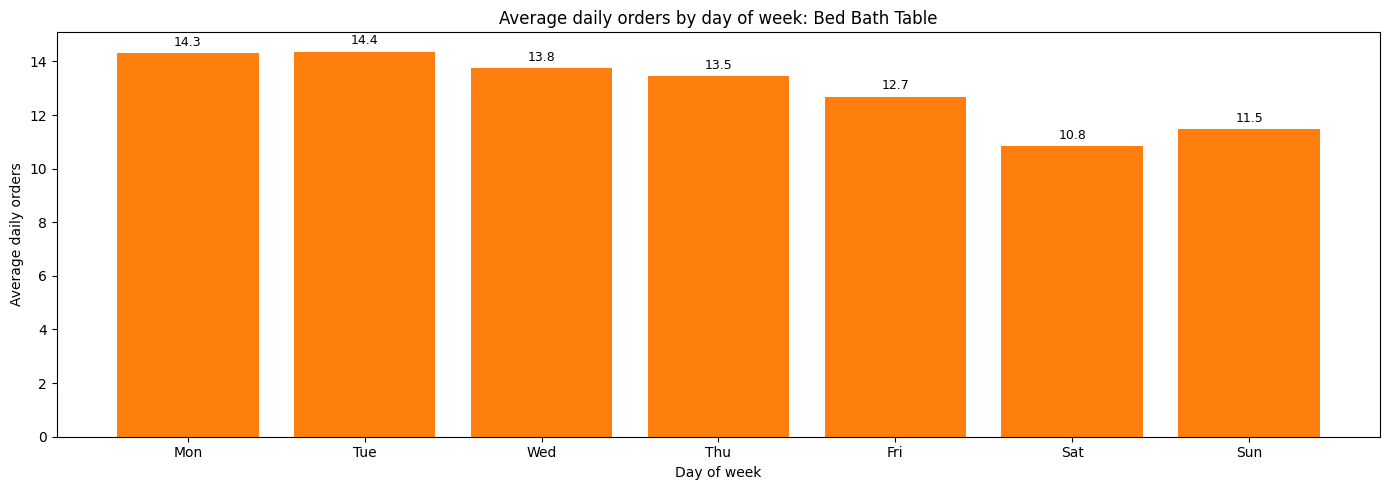

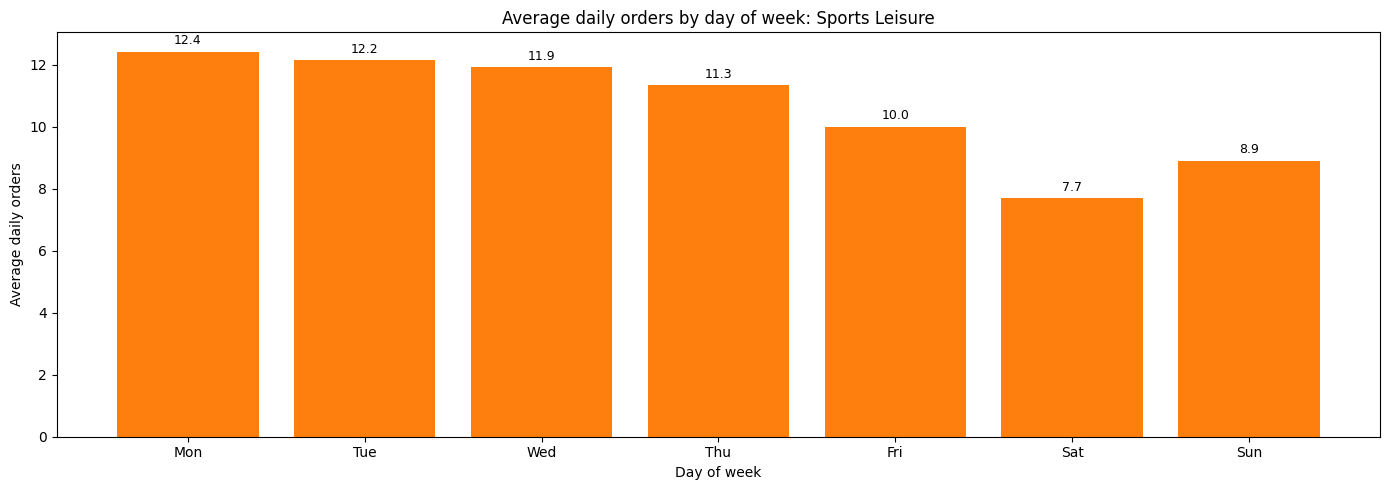

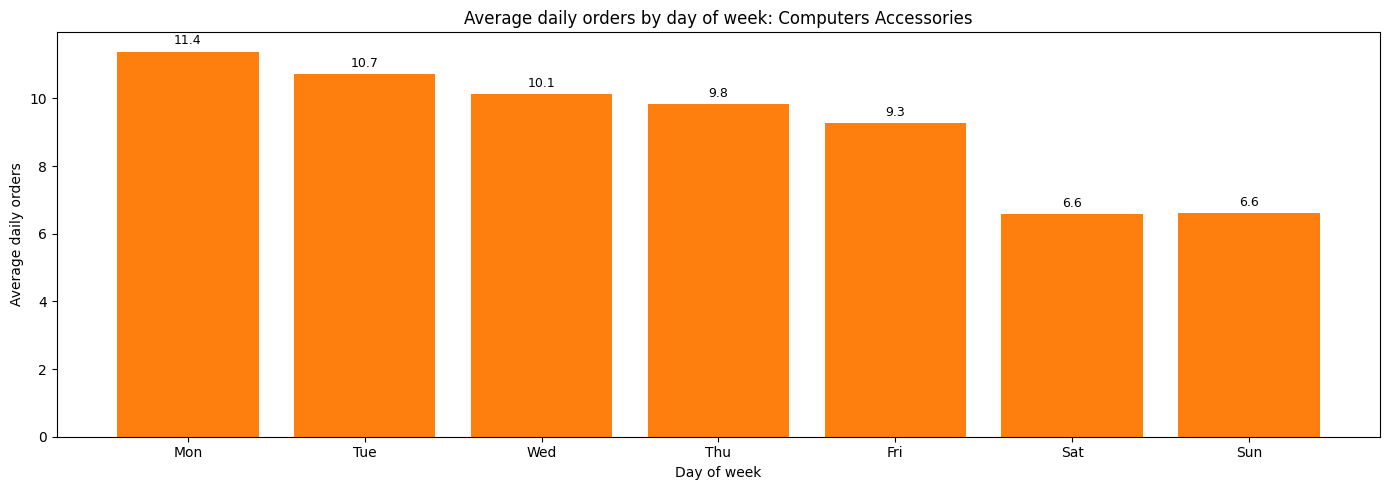

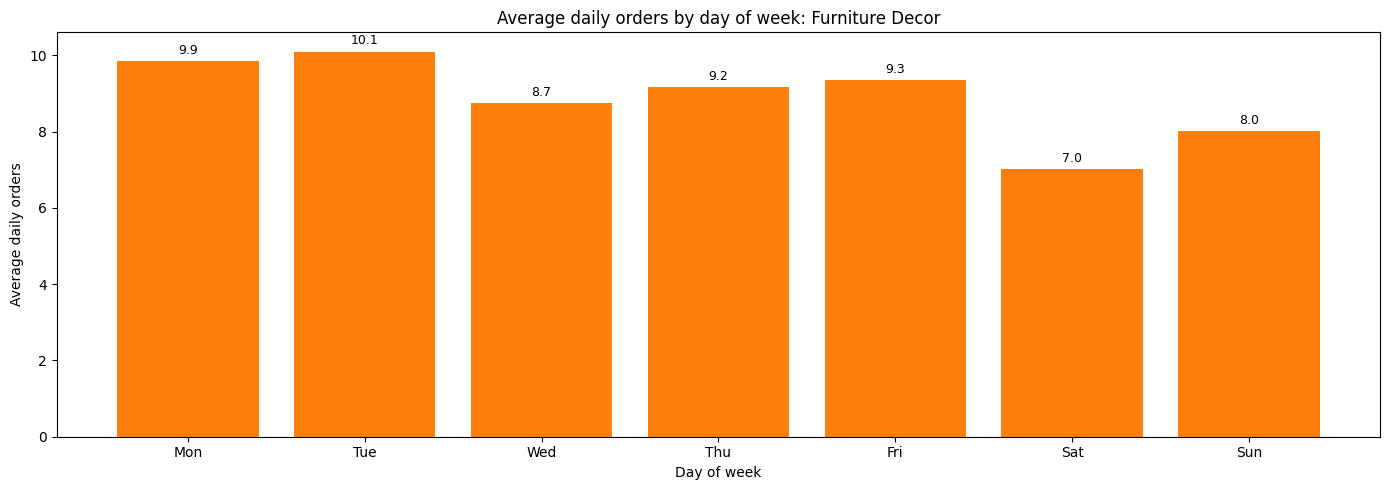

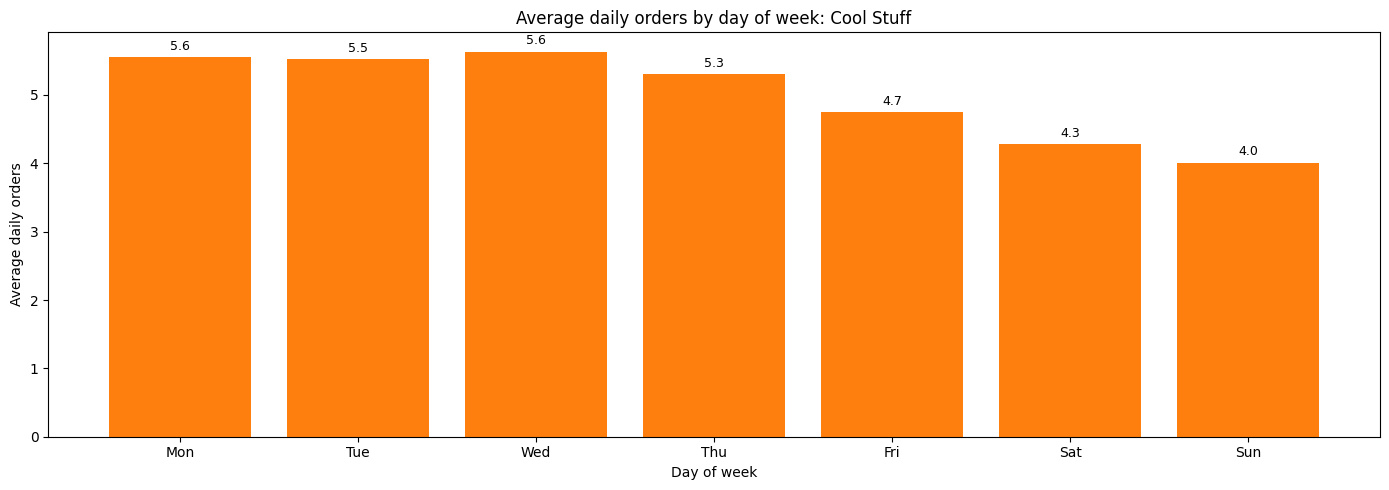

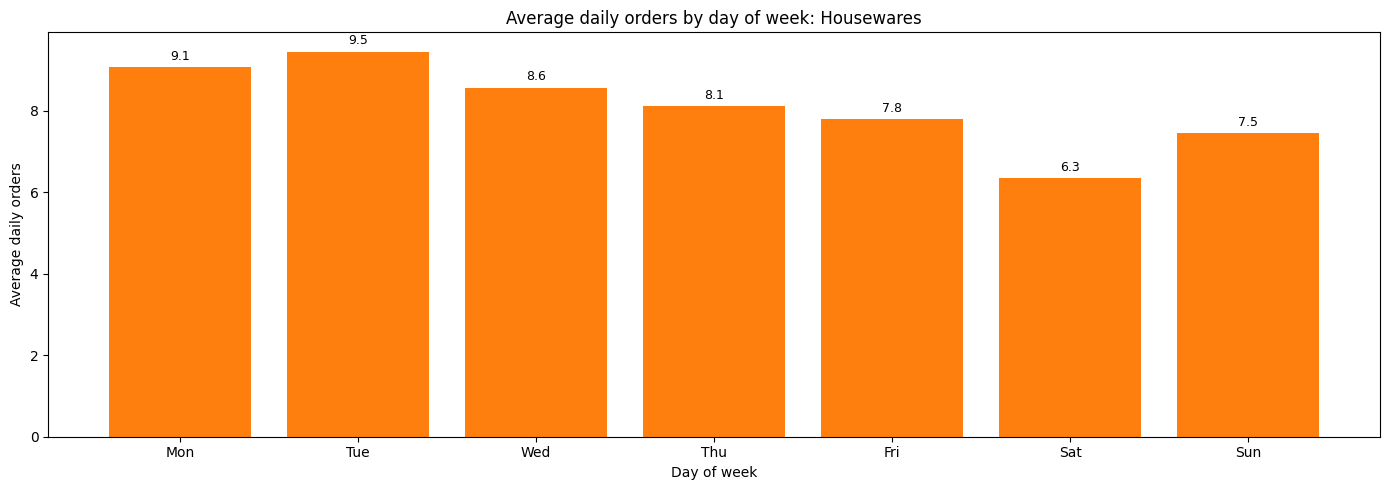

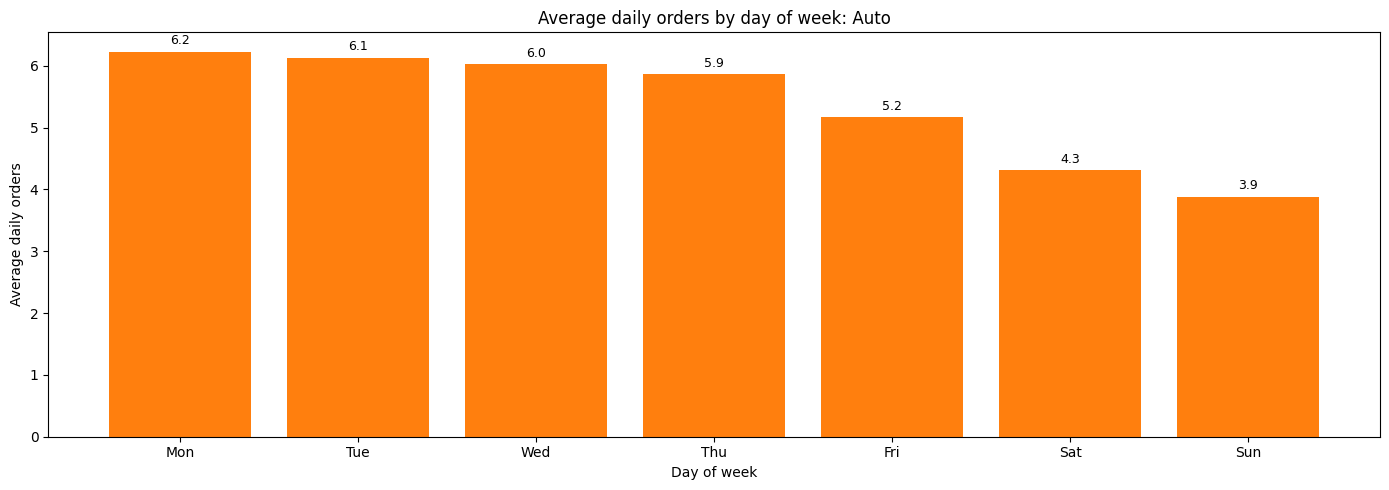

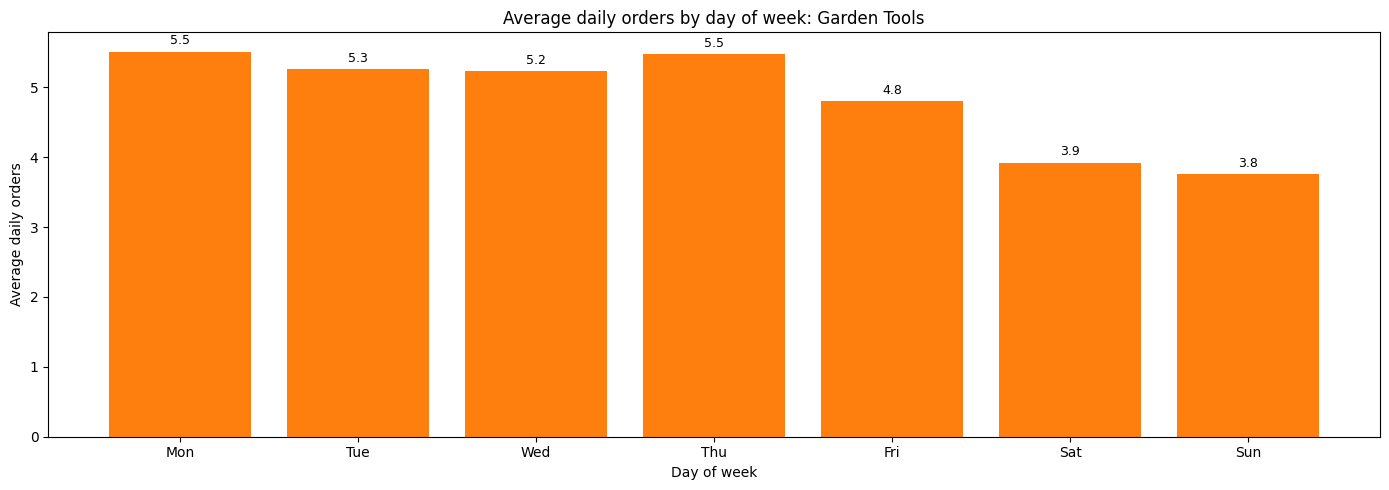

In [12]:
for cat in top10_categories:
    sub = dow_profile[dow_profile["category"] == cat].sort_values("dow_name")
    plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    ax.bar(sub["dow_name"].astype(str), sub["orders"], color=ORANGE)

    scale, suffix = apply_y_axis_format(ax, sub["orders"])
    add_bar_value_labels(ax, scale, suffix)

    ax.set_title(f"Average daily orders by day of week: {pretty_category(cat)}")
    ax.set_xlabel("Day of week")
    ax.set_ylabel("Average daily orders")
    plt.tight_layout()
    plt.show()

Day of week profiles show a consistent operational rhythm, with Saturday and Sunday registering the lowest average daily orders across all categories analyzed. Month of year profiles show that the last third of the year tends to be softer, with September through December presenting lower average daily orders than most other months. This is counter to what might be expected from end of year gift season dynamics in Brazil. Within that weaker September to December block, November is typically the relatively strongest month. Garden Tools is the clear exception, with November appearing as the highest month of the year for that category.

These historical patterns provide the context needed to interpret baseline references and projected signals in the next sections.


## Baseline demand reference

With historical seasonality established, the baseline acts as a stable reference for expected order volume under normal conditions. It is not intended to be a competitive forecast model. The goal is to keep a simple anchor that makes seasonal patterns visible and reduces the temptation to over interpret daily noise.

The baseline here is a weekly seasonal naive reference. For each day, it uses the observed volume from one week earlier. This baseline captures weekly seasonality without fitting a model.

In [13]:
def seasonal_naive_series(y, season_length=7):
    y = np.asarray(y)
    out = np.empty_like(y, dtype=float)
    out[:] = np.nan
    if len(y) <= season_length:
        return out
    out[season_length:] = y[:-season_length]
    return out

baseline_frames = []
for cat in top10_categories:
    sub = daily_cat[daily_cat["category"] == cat].sort_values("date").copy()
    sub["baseline"] = seasonal_naive_series(sub["orders"].values, season_length=7)
    baseline_frames.append(sub)

daily_with_baseline = pd.concat(baseline_frames, ignore_index=True)
daily_with_baseline.head()

,category,date,orders,month,month_name,dow,dow_name,baseline
0,health_beauty,2016-09-04,0.0,9,Sep,6,Sun,NaN
1,health_beauty,2016-09-05,0.0,9,Sep,0,Mon,NaN
2,health_beauty,2016-09-06,0.0,9,Sep,1,Tue,NaN
3,health_beauty,2016-09-07,0.0,9,Sep,2,Wed,NaN
4,health_beauty,2016-09-08,0.0,9,Sep,3,Thu,NaN


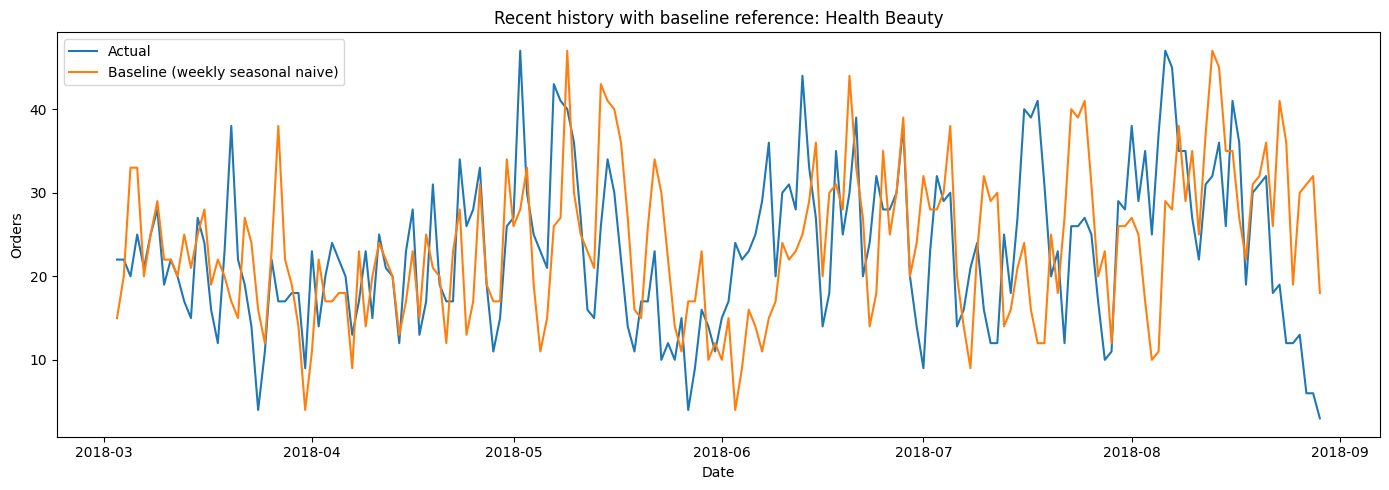

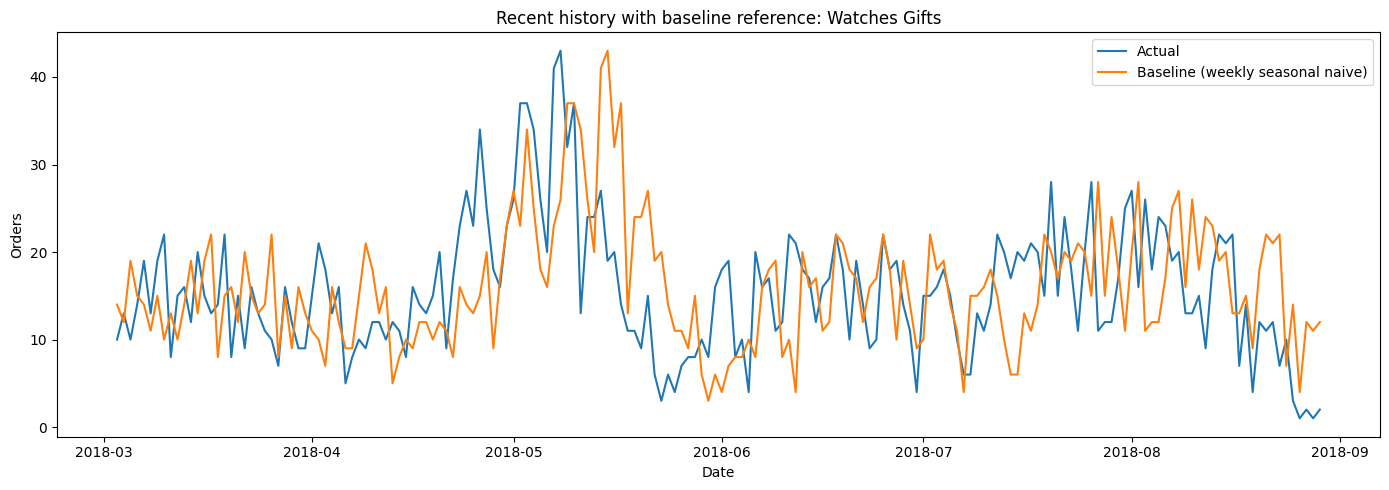

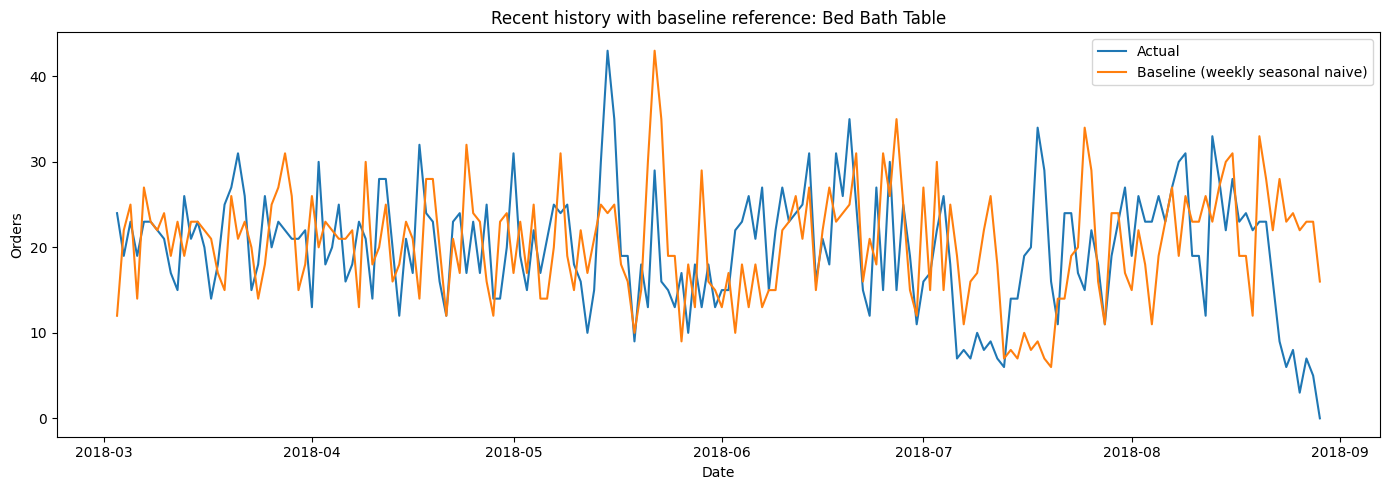

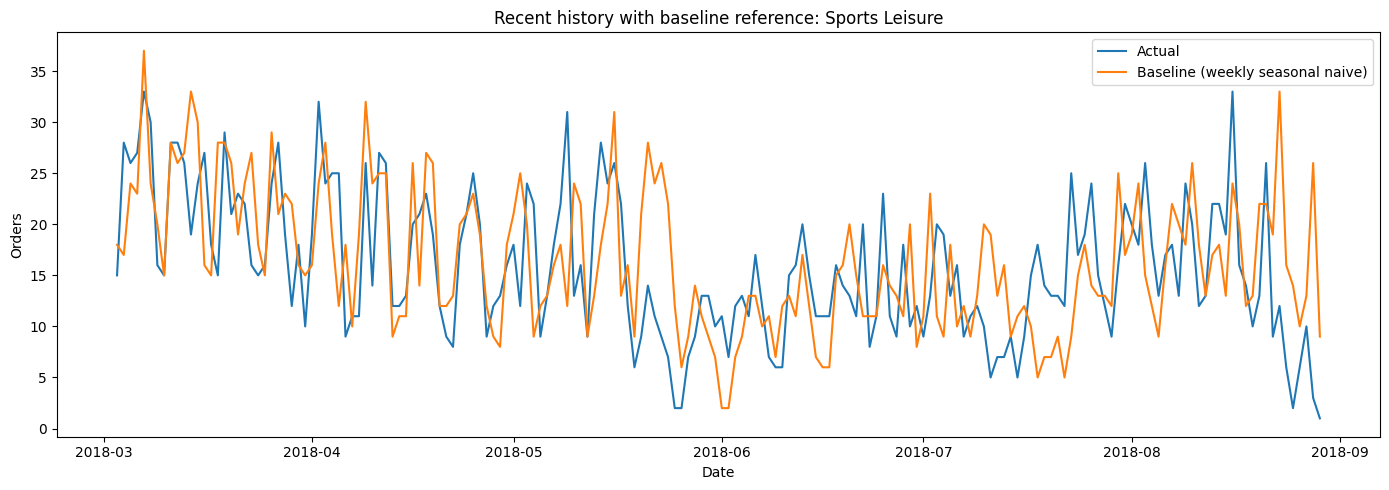

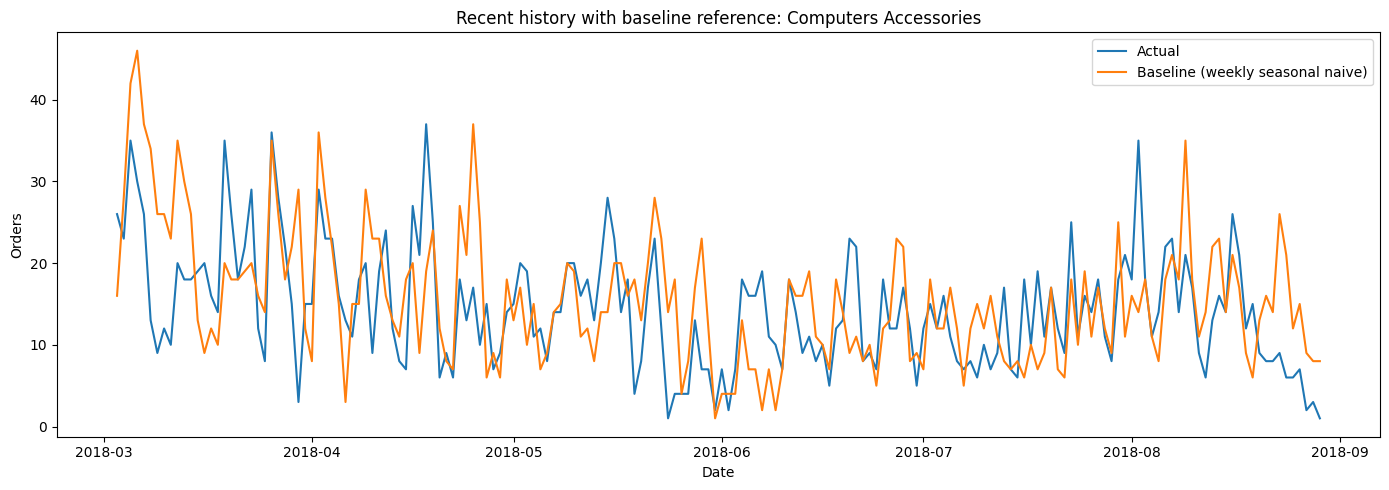

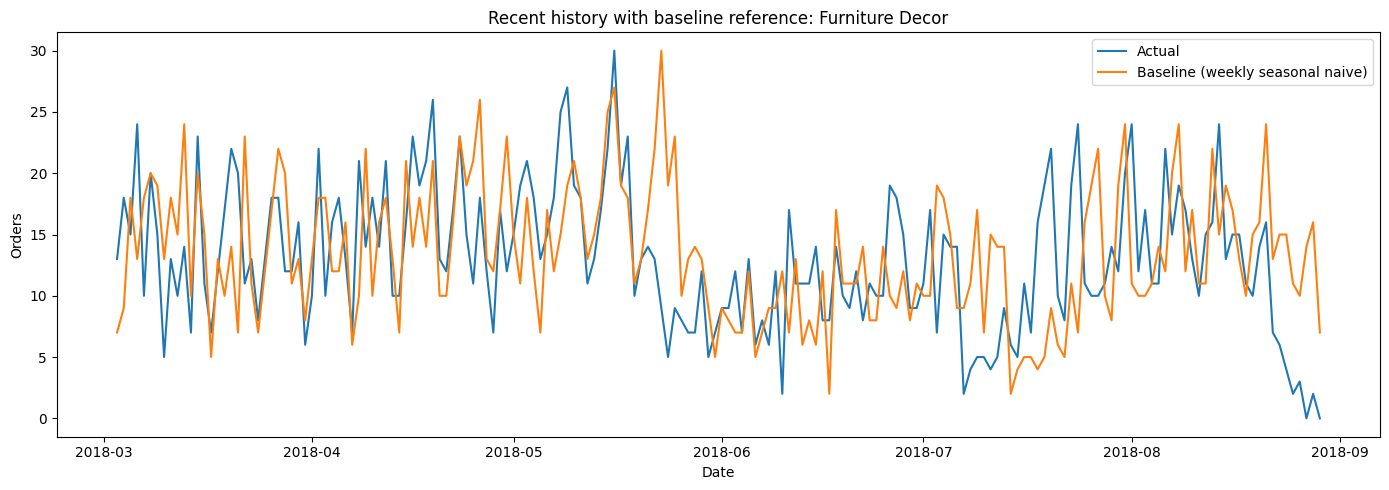

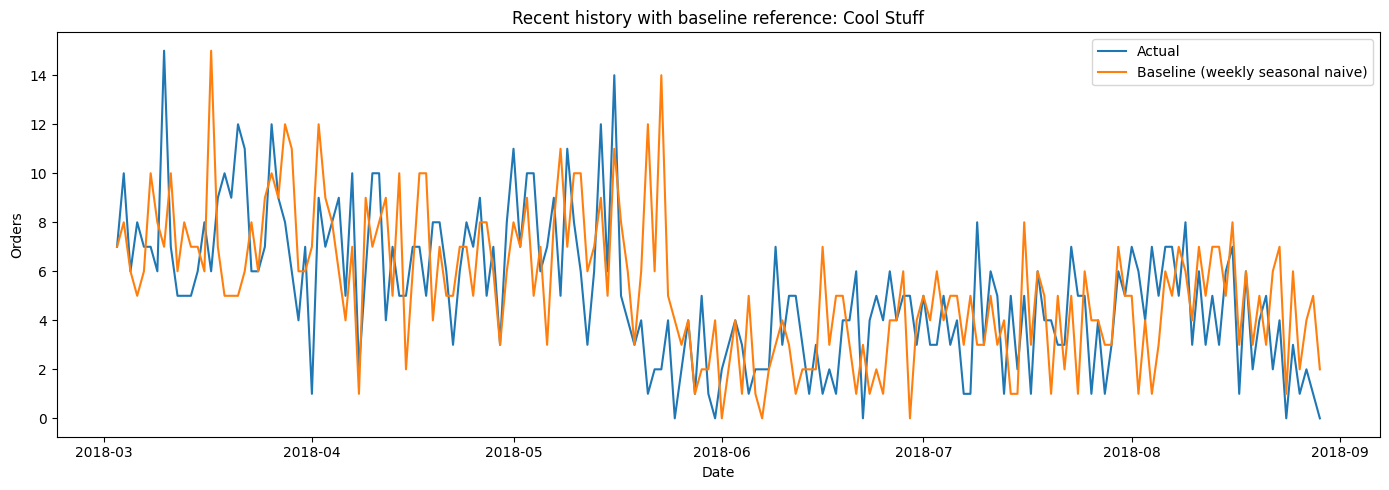

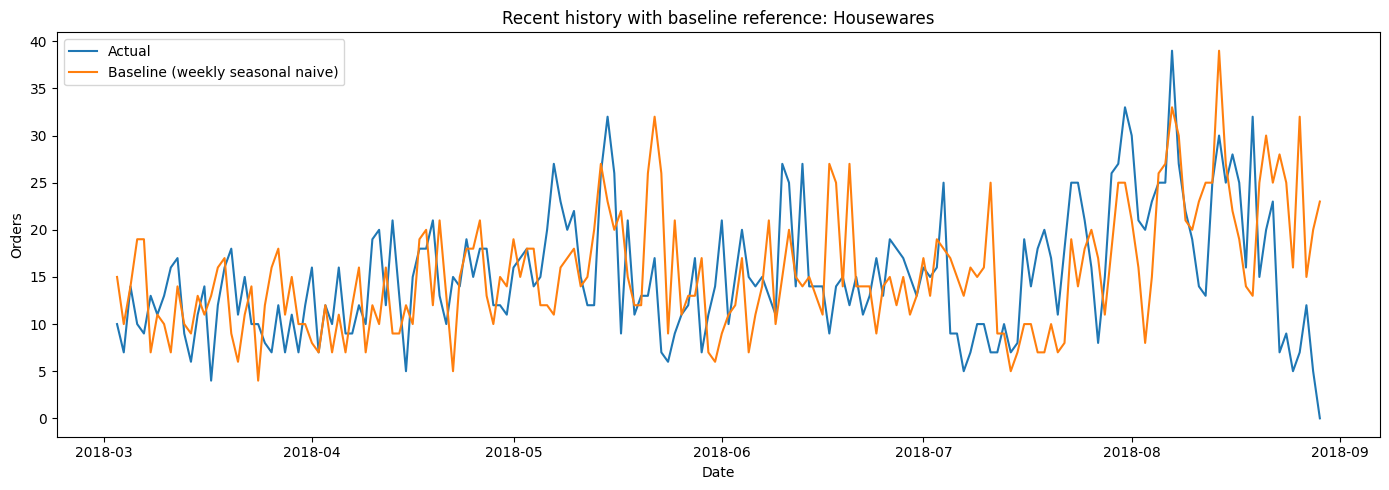

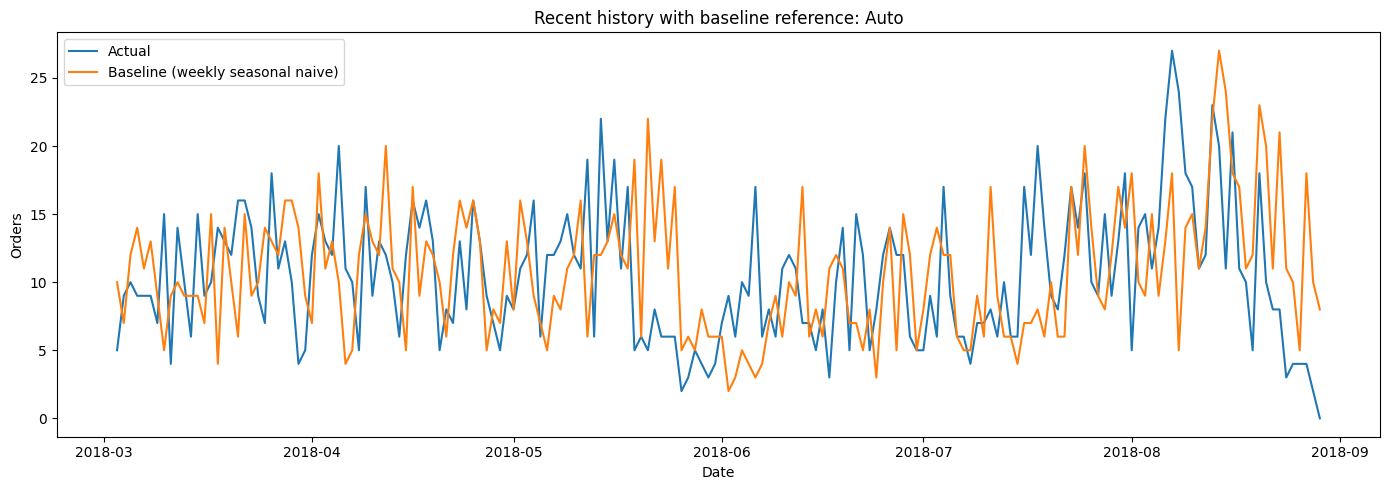

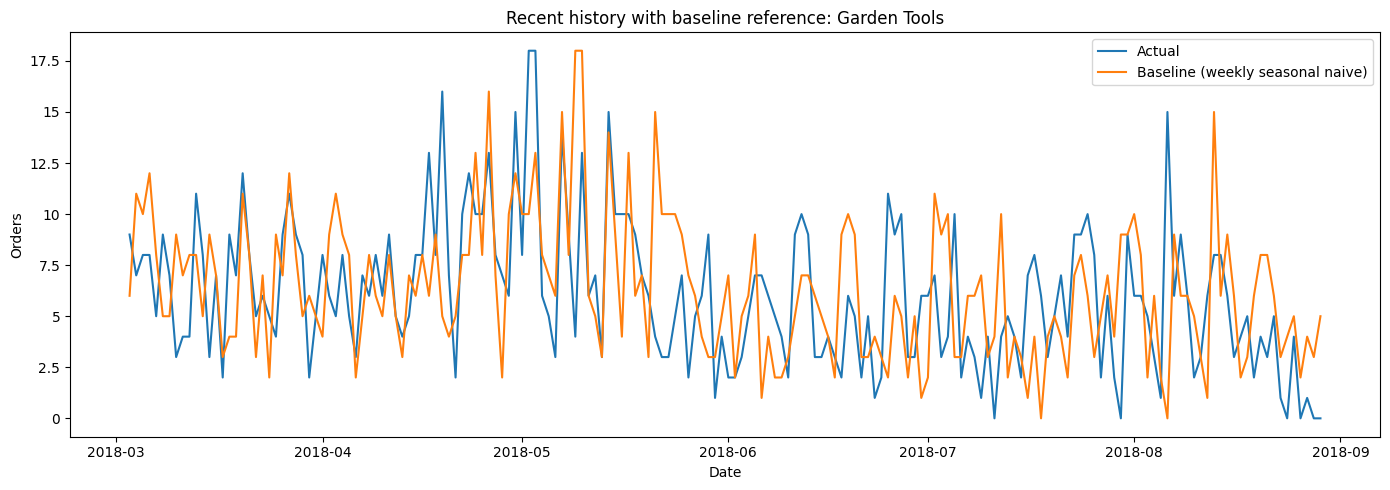

In [14]:
FIGSIZE = (14, 5)
plt.rcParams["figure.figsize"] = FIGSIZE
for cat in top10_categories:
    sub = daily_with_baseline[daily_with_baseline["category"] == cat].copy()
    recent = sub.tail(180)
    plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    ax.plot(recent["date"], recent["orders"], color=BLUE, label="Actual")
    ax.plot(recent["date"], recent["baseline"], color=ORANGE, label="Baseline (weekly seasonal naive)")

    apply_y_axis_format(ax, pd.concat([recent["orders"], recent["baseline"]], ignore_index=True))

    ax.set_title(f"Recent history with baseline reference: {pretty_category(cat)}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Orders")
    ax.legend()
    plt.tight_layout()
    plt.show()

For most categories, recent actual order volume tracks closely to the weekly seasonal naive baseline, with small deviations that are expected in day to day operations. This makes the baseline a useful reference for normal weekly rhythm. Garden Tools stands out because the gap between actual orders and the baseline is frequent and often more pronounced than in other categories, which suggests higher volatility and a greater need for monitoring when planning short term capacity.

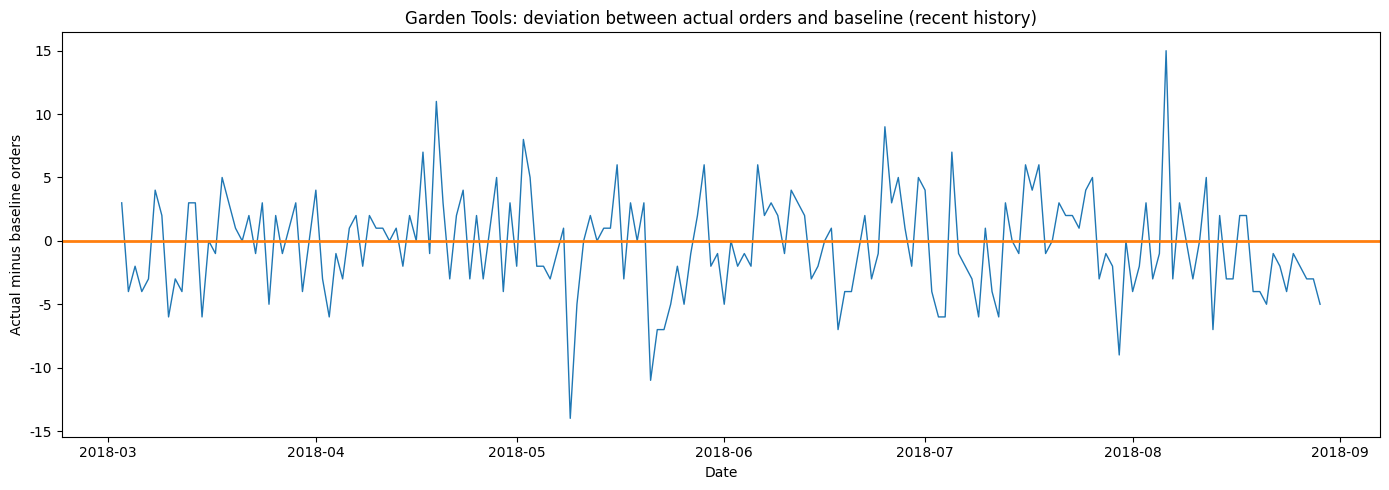

In [15]:
FIGSIZE = (14, 5)
plt.rcParams["figure.figsize"] = FIGSIZE
# Deviation view for the most volatile category
cat = "garden_tools"
sub = daily_with_baseline[daily_with_baseline["category"] == cat].copy()
sub = sub.dropna(subset=["baseline"]).sort_values("date")
sub["deviation"] = sub["orders"] - sub["baseline"]

recent = sub.tail(180)

plt.figure(figsize=FIGSIZE)
ax = plt.gca()
ax.plot(recent["date"], recent["deviation"], color=BLUE, linewidth=1)
ax.axhline(0, color=ORANGE, linewidth=2)

apply_y_axis_format(ax, recent["deviation"])

ax.set_title("Garden Tools: deviation between actual orders and baseline (recent history)")
ax.set_xlabel("Date")
ax.set_ylabel("Actual minus baseline orders")
plt.tight_layout()
plt.show()

Viewing the deviation directly makes the pattern easier to read than overlapping lines. Values close to zero indicate days where the baseline is a good reference. Repeated spikes away from zero indicate frequent mismatches between actual intake and the weekly rhythm, reinforcing that Garden Tools behaves less regularly than the other top categories.

## Forecast as a signal extension

A lightweight forecasting model can extend the seasonal patterns forward and provide an early signal for upcoming high demand periods. In this project, forecasting is treated as a way to project recurring patterns, not as a promise of exact future volume. The model is used to produce a smooth expectation line and an uncertainty band.

Prophet is a time series forecasting model that decomposes historical order volume into trend and seasonal components. It is used here because it provides an interpretable decomposition of trend and seasonality and works well for business facing time series.

In [16]:
def ensure_prophet():
    try:
        from prophet import Prophet  # noqa: F401
        return True
    except Exception:
        return False

ensure_prophet()

In [17]:
# If Prophet is not available, this cell installs it in the current environment.
if not ensure_prophet():
    import sys
    !{sys.executable} -m pip -q install prophet

In [18]:
from prophet import Prophet

def fit_prophet_and_forecast(category_df, periods=365, interval_width=0.80):
    df = category_df.rename(columns={"date": "ds", "orders": "y"})[["ds", "y"]].copy()
    m = Prophet(
        weekly_seasonality=True,
        yearly_seasonality=True,
        daily_seasonality=False,
        interval_width=interval_width,
    )
    m.fit(df)
    future = m.make_future_dataframe(periods=periods, freq="D", include_history=True)
    fc = m.predict(future)[["ds", "yhat", "yhat_lower", "yhat_upper"]]
    return m, df, fc

prophet_outputs = {}
for cat in top10_categories:
    sub = daily_cat[daily_cat["category"] == cat].sort_values("date").copy()
    model, df_train, fc = fit_prophet_and_forecast(sub, periods=365, interval_width=0.80)
    prophet_outputs[cat] = {"model": model, "train": df_train, "forecast": fc}

list(prophet_outputs.keys())[:3], prophet_outputs[top10_categories[0]]["forecast"].tail(3)

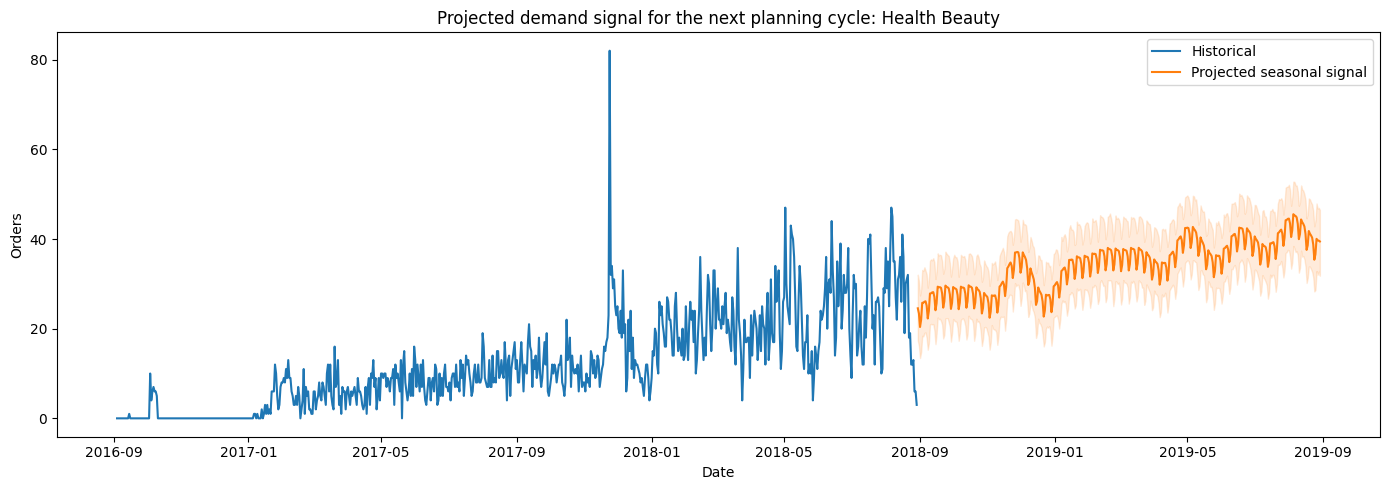

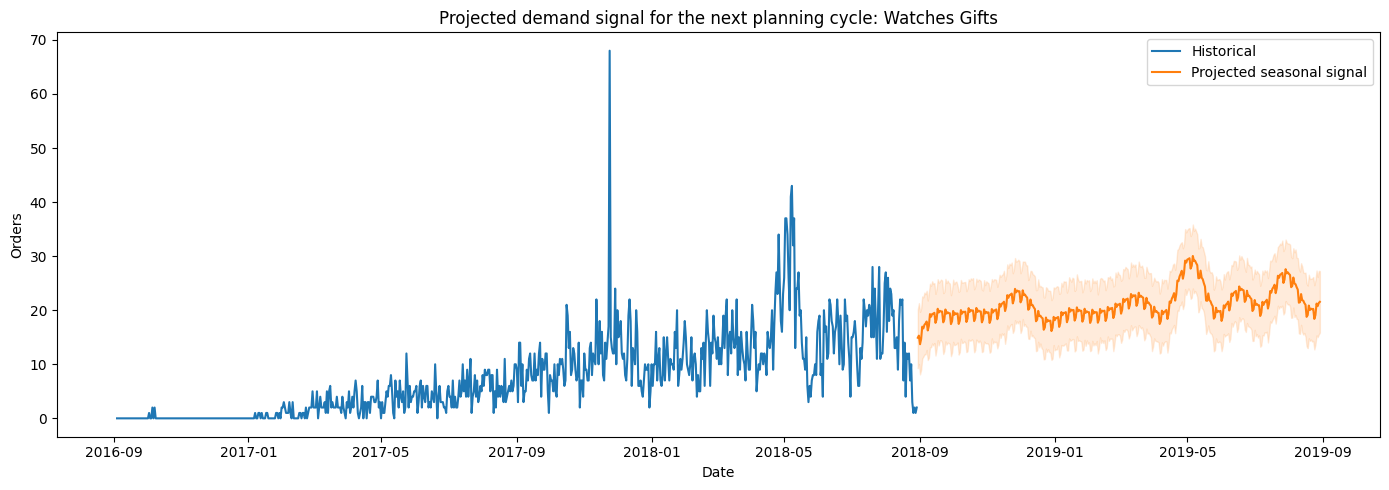

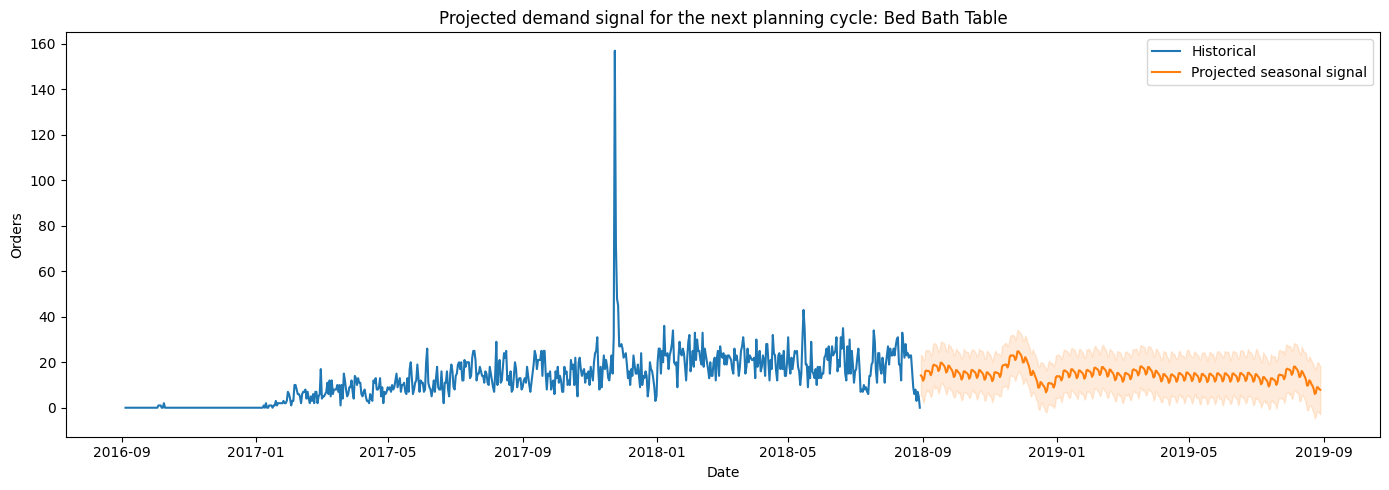

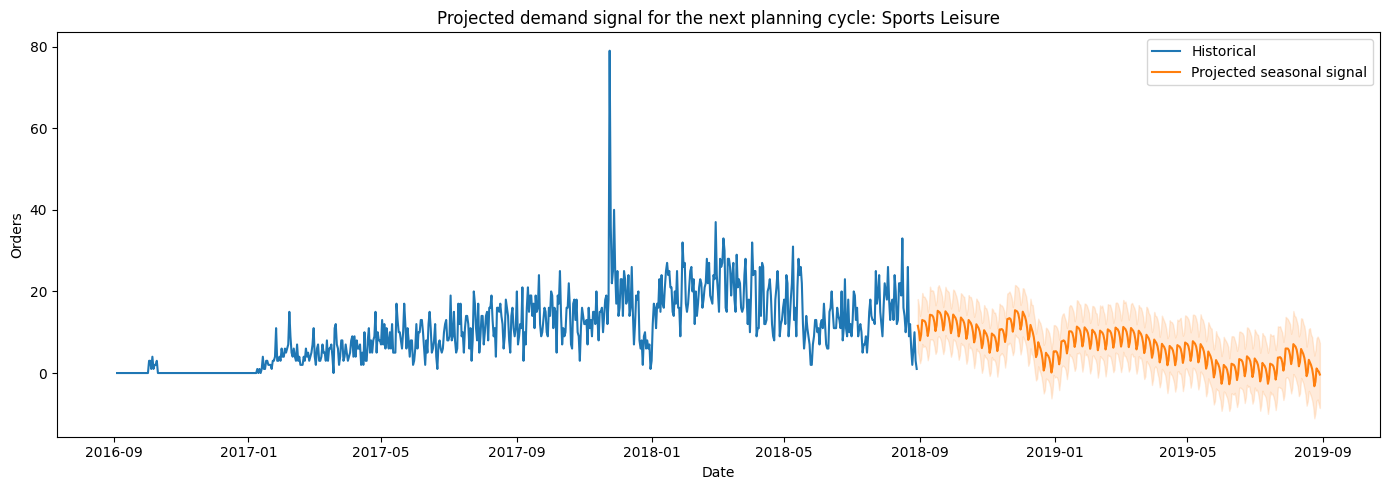

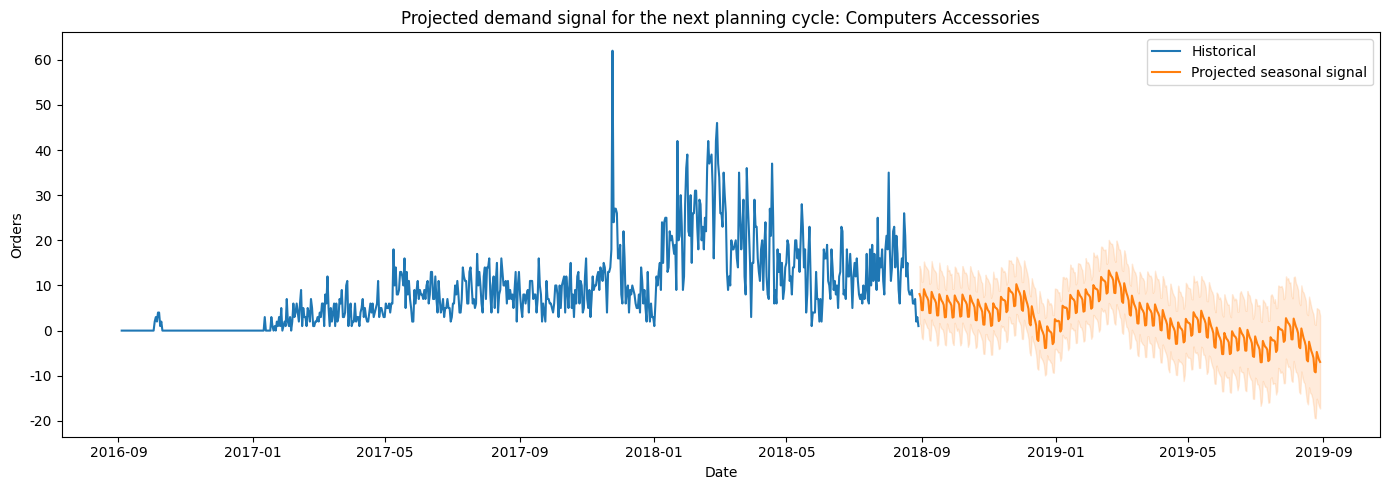

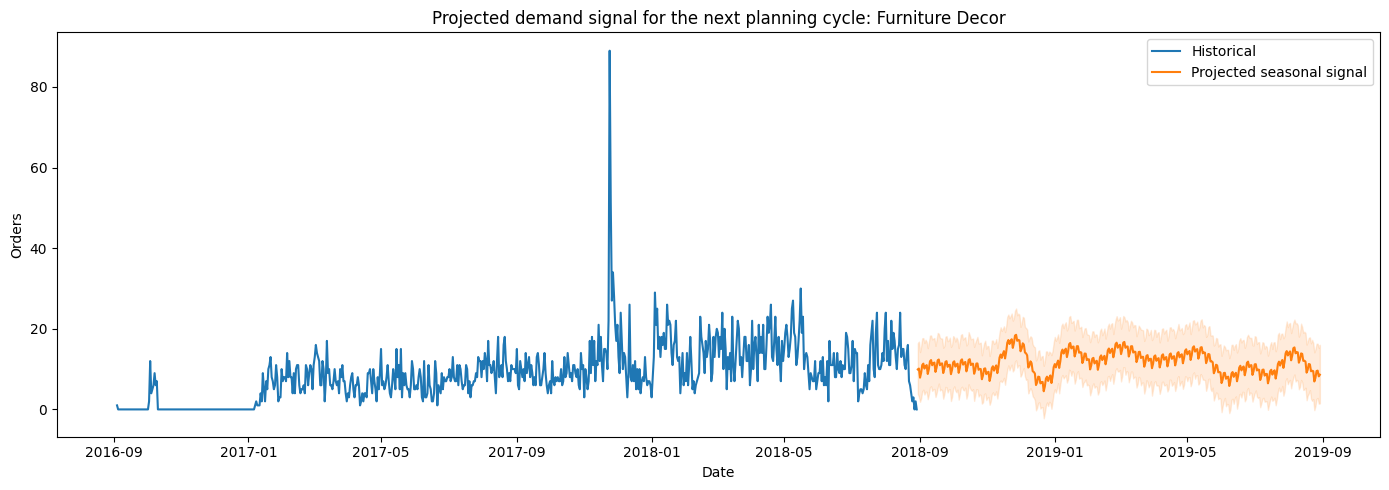

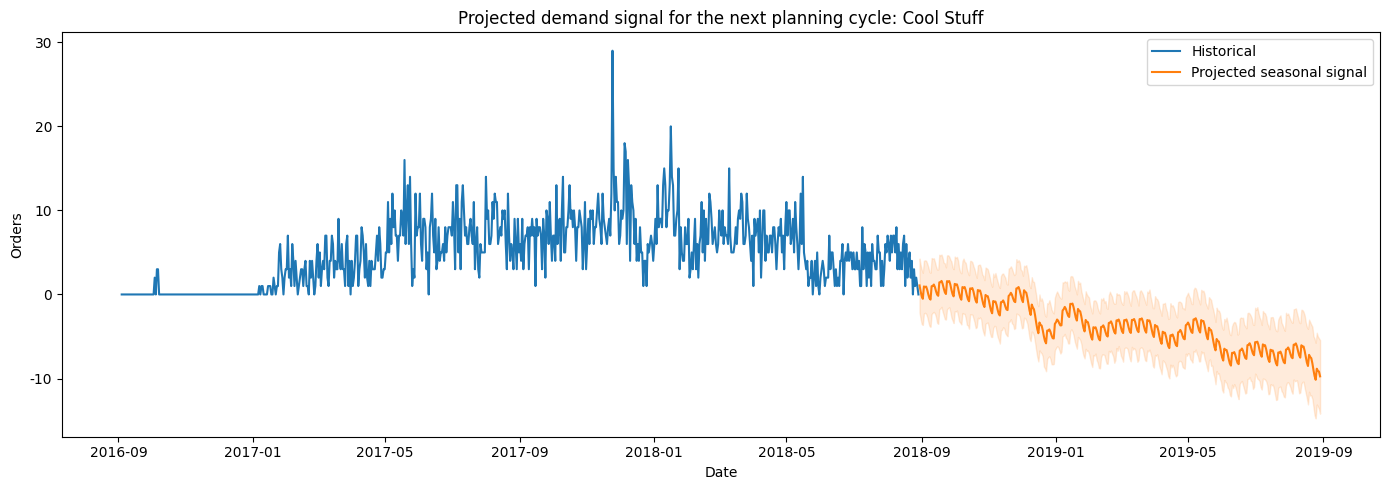

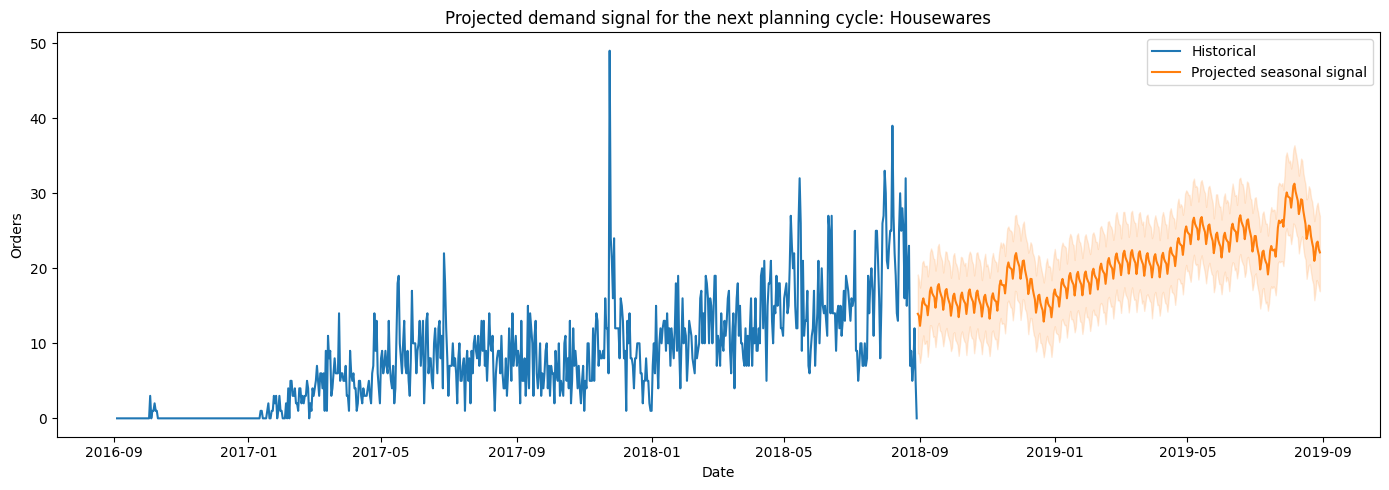

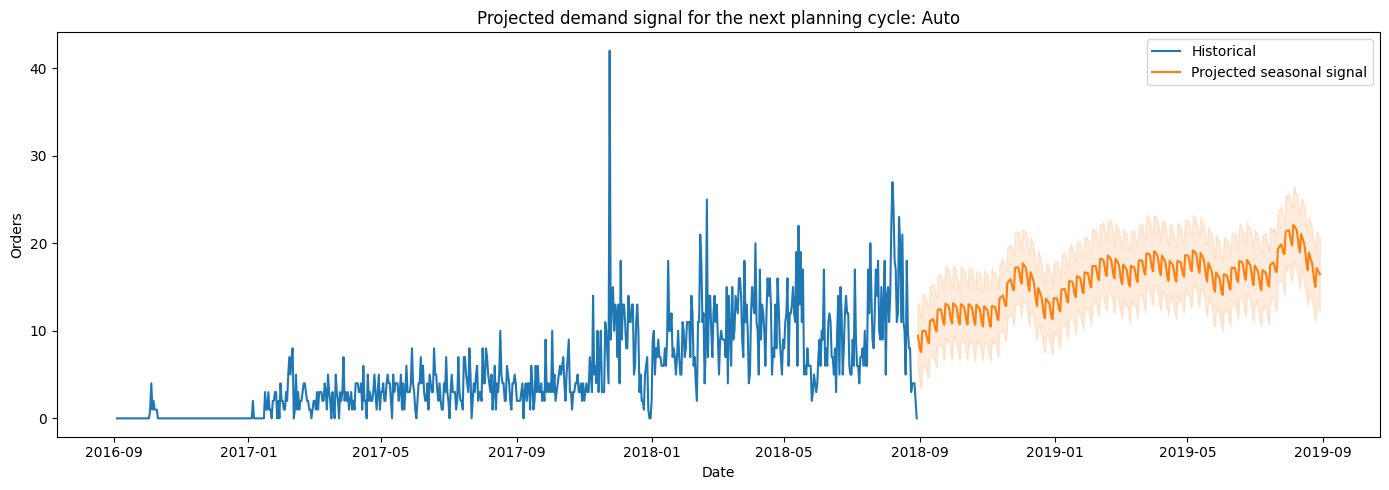

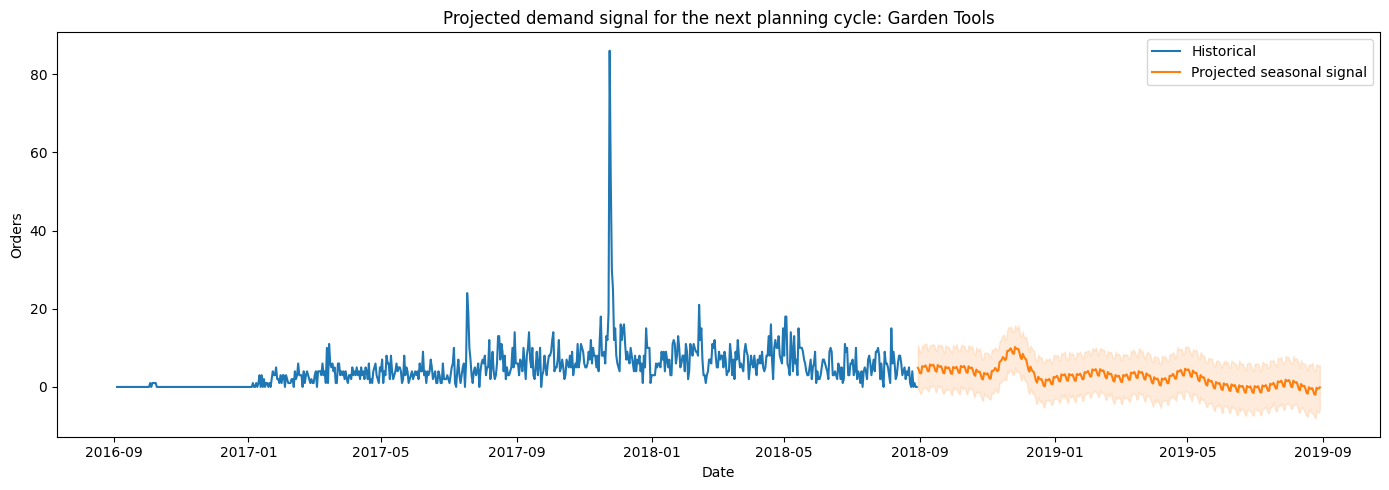

In [19]:
FIGSIZE = (14, 5)
plt.rcParams["figure.figsize"] = FIGSIZE
for cat in top10_categories:
    df_train = prophet_outputs[cat]["train"]
    fc = prophet_outputs[cat]["forecast"]

    last_hist_day = df_train["ds"].max()
    fc_future = fc[fc["ds"] > last_hist_day].copy()

    plt.figure(figsize=FIGSIZE)
    ax = plt.gca()
    ax.plot(df_train["ds"], df_train["y"], color=BLUE, label="Historical")
    ax.plot(fc_future["ds"], fc_future["yhat"], color=ORANGE, label="Projected seasonal signal")
    ax.fill_between(fc_future["ds"], fc_future["yhat_lower"], fc_future["yhat_upper"], alpha=0.15, color=ORANGE)

    apply_y_axis_format(ax, pd.concat([df_train["y"], fc_future["yhat"]], ignore_index=True))

    ax.set_title(f"Projected demand signal for the next planning cycle: {pretty_category(cat)}")
    ax.set_xlabel("Date")
    ax.set_ylabel("Orders")
    ax.legend()
    plt.tight_layout()
    plt.show()

In this section, the orange line is a projected seasonal signal that extends beyond the historical window. It is best interpreted as early visibility into when order intake may become more intense, not as a guarantee of exact outcomes. Across categories, the projected signal often shows a modest lift around November 2018. Additional category specific windows stand out in 2019, including a May to June lift for Watches & Gifts, a June through August lift for Health & Beauty, and August lifts for Auto and Housewares. Computers & Accessories shows a smaller lift around March 2019. Several categories remain comparatively stable, where the projected line moves only slightly and suggests limited seasonal pressure. The practical goal is to translate these projected windows into earlier preparation and buffer planning, rather than to optimize for precision.

## Note on Geographic Extension

While this notebook focuses primarily on analyzing demand signals and projecting order volume over time, a complementary geographic analysis was developed to further explore regional dynamics across Brazil.

To extend the analysis beyond the temporal dimension, an interactive dashboard was created. This dashboard enables a deeper exploration of order demand at both national and state levels.

The dashboard serves as an interactive extension of this analysis, offering a visual and exploratory perspective that complements the insights derived here.

https://public.tableau.com/views/OlistRegionalOrderDemandandProjection/Painel1?:language=pt-BR&:sid=&:redirect=auth&:display_count=n&:origin=viz_share_link


## Key patterns

The core insight from this analysis is that operational pressure, expressed as order volume, tends to concentrate in short and category specific windows rather than appearing as a long, uniform seasonal peak. This supports planning approaches that emphasize targeted readiness over broad, month long scaling assumptions.

A second important insight is that the end of year period is weaker than expected, despite the common assumption of sustained holiday driven demand. Within the September to December window, November stands out as a relative local high point rather than the strongest month of the year overall. Garden Tools is the main exception, with November aligning with the highest average daily order volume across the year.

A simple weekly baseline is sufficient to describe normal behavior in most categories and to separate routine variability from meaningful deviations. Where the actual series frequently diverges from the baseline, as seen in Garden Tools, closer category specific monitoring becomes more important.

Forecasts in this project are used as an extension of observed seasonal structure rather than as deterministic predictions of exact future volumes. They are best interpreted as directional signals that can be used to stress test operational readiness and to plan for potential short windows of higher pressure.


These patterns are most useful when translated into planning windows and operational triggers. The goal is not to forecast an exact number of orders for a specific day, but to identify when capacity, staffing, and seller preparedness are more likely to be tested, and when a lighter operating posture is likely to be sufficient.

## Practical applications

Sellers can use these signals to plan inventory positioning, staffing, and fulfillment throughput around short windows where higher order pressure is more likely. Rather than treating the entire end of year period as a sustained peak, planning can focus on the specific months and categories where the signal is stronger, with additional attention given to categories that behave differently from the general pattern.

From the marketplace intermediary perspective, the same logic can be used to publish category level readiness guidance to sellers, aligning operational expectations across the ecosystem. This supports more efficient scaling decisions by targeting preparation where it is most likely to matter and avoiding unnecessary capacity expansion during periods that appear strong by intuition but are weaker in the historical record.


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=5562491b-a98e-4925-a811-76400f1e61c7' target="_blank">
 </img>
Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>